In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\ADMIN\FinGraph-Sentinel")
DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = DATA_DIR / "results"
PHASE15_DIR = RESULTS_DIR / "phase15"
PHASE16_DIR = RESULTS_DIR / "phase16"

PHASE16_DIR.mkdir(parents=True, exist_ok=True)

validation_df = pd.read_csv(
    RESULTS_DIR / "phase14" / "multi_signal_risk_validation.csv"
)

validation_df["date"] = pd.to_datetime(validation_df["date"])

validation_df = validation_df.sort_values(
    ["date"]
).reset_index(drop=True)

print("Dataset shape:", validation_df.shape)
print("Date range:", validation_df["date"].min(), "to", validation_df["date"].max())
print("Missing values:", validation_df.isna().sum().sum())

display(validation_df.head())

Dataset shape: (1180, 9)
Date range: 2021-11-12 00:00:00 to 2026-07-16 00:00:00
Missing values: 0


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,exploratory_risk_category,future_stress_event
0,2021-11-12,0.585833,0.392917,0.795833,0.566667,0.585312,62.250000,Moderate,0
1,2021-11-12,0.585833,0.817917,0.809167,0.596667,0.702396,80.916667,High,0
2,2021-11-12,0.585833,0.817917,0.868333,0.605000,0.719271,82.416667,High,0
3,2021-11-12,0.109583,0.392917,0.070833,0.070833,0.161042,7.083333,Lower,0
4,2021-11-12,0.315000,0.392917,0.775417,0.342083,0.456354,39.875000,Lower,0


In [2]:
date_level_df = (
    validation_df
    .groupby("date")
    .agg(
        degree=("degree", "mean"),
        betweenness=("betweenness", "mean"),
        pagerank=("pagerank", "mean"),
        systemic_risk_score=("systemic_risk_score", "mean"),
        multi_signal_risk_score=("multi_signal_risk_score", "mean"),
        risk_percentile=("risk_percentile", "mean"),
        total_companies=("future_stress_event", "count"),
        stress_events=("future_stress_event", "sum")
    )
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

date_level_df["date_stress_event"] = (
    date_level_df["stress_events"] > 0
).astype(int)

print("Date-level shape:", date_level_df.shape)
print(
    "Stress-event distribution:\n",
    date_level_df["date_stress_event"].value_counts()
)

display(date_level_df.head())

Date-level shape: (118, 10)
Stress-event distribution:
 date_stress_event
0    102
1     16
Name: count, dtype: int64


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,total_companies,stress_events,date_stress_event
0,2021-11-12,0.377958,0.520417,0.545250,0.366333,0.452490,44.075000,10,0,0
1,2021-11-29,0.393958,0.477917,0.541625,0.380458,0.448490,42.845833,10,0,0
2,2021-12-13,0.393958,0.477917,0.536833,0.379167,0.446969,42.479167,10,0,0
3,2021-12-28,0.396792,0.477917,0.561042,0.388125,0.455969,44.658333,10,10,1
4,2022-01-11,0.396792,0.477917,0.561375,0.388042,0.456031,44.679167,10,0,0


In [3]:
signal_columns = [
    "degree",
    "betweenness",
    "pagerank",
    "systemic_risk_score",
    "multi_signal_risk_score",
    "risk_percentile"
]

feature_df = date_level_df.copy()

for signal in signal_columns:
    feature_df[f"{signal}_change"] = (
        feature_df[signal].diff()
    )

    feature_df[f"{signal}_rolling_mean_3"] = (
        feature_df[signal]
        .rolling(window=3, min_periods=3)
        .mean()
        .shift(1)
    )

    feature_df[f"{signal}_rolling_std_3"] = (
        feature_df[signal]
        .rolling(window=3, min_periods=3)
        .std()
        .shift(1)
    )

    feature_df[f"{signal}_zscore_3"] = (
        (
            feature_df[signal]
            - feature_df[f"{signal}_rolling_mean_3"]
        )
        /
        feature_df[f"{signal}_rolling_std_3"].replace(0, np.nan)
    )

feature_df = feature_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Feature dataset shape:", feature_df.shape)
print("Missing values after feature construction:")
display(feature_df.isna().sum().sort_values(ascending=False).head(15))

Feature dataset shape: (118, 34)
Missing values after feature construction:


betweenness_zscore_3                      13
degree_zscore_3                            6
multi_signal_risk_score_zscore_3           3
risk_percentile_rolling_mean_3             3
degree_rolling_mean_3                      3
degree_rolling_std_3                       3
betweenness_rolling_mean_3                 3
betweenness_rolling_std_3                  3
risk_percentile_rolling_std_3              3
risk_percentile_zscore_3                   3
multi_signal_risk_score_rolling_mean_3     3
multi_signal_risk_score_rolling_std_3      3
systemic_risk_score_rolling_std_3          3
systemic_risk_score_zscore_3               3
systemic_risk_score_rolling_mean_3         3
dtype: int64

In [4]:
# Remove early rows without sufficient historical information
model_df = feature_df.dropna().copy()

# Confirm chronological ordering
model_df = model_df.sort_values("date").reset_index(drop=True)

# Identify generated temporal features
temporal_features = [
    column
    for column in model_df.columns
    if (
        "_change" in column
        or "_rolling_mean_3" in column
        or "_rolling_std_3" in column
        or "_zscore_3" in column
    )
]

print("Prepared dataset shape:", model_df.shape)
print("Temporal features:", len(temporal_features))
print("Remaining missing values:", model_df.isna().sum().sum())

display(model_df[[
    "date",
    "date_stress_event",
    *temporal_features[:6]
]].head())

Prepared dataset shape: (103, 34)
Temporal features: 24
Remaining missing values: 0


,date,date_stress_event,degree_change,degree_rolling_mean_3,degree_rolling_std_3,degree_zscore_3,betweenness_change,betweenness_rolling_mean_3
0,2021-12-28,1,0.002833,0.388625,0.009238,0.884068,0.000000,0.492083
1,2022-02-09,1,0.018167,0.438625,0.072457,1.405422,0.084375,0.497417
2,2022-02-24,0,0.111875,0.486514,0.078231,2.119617,0.011875,0.545042
3,2022-03-10,0,0.023417,0.571694,0.070424,1.477567,-0.046250,0.596625
4,2022-03-24,0,0.043542,0.622847,0.072305,1.333853,-0.051000,0.613292


In [5]:
stress_temporal_comparison = []

for feature in temporal_features:
    stress_values = model_df.loc[
        model_df["date_stress_event"] == 1,
        feature
    ]

    normal_values = model_df.loc[
        model_df["date_stress_event"] == 0,
        feature
    ]

    stress_temporal_comparison.append({
        "feature": feature,
        "stress_mean": stress_values.mean(),
        "normal_mean": normal_values.mean(),
        "mean_difference": (
            stress_values.mean() - normal_values.mean()
        ),
        "stress_std": stress_values.std(),
        "normal_std": normal_values.std()
    })

temporal_comparison_df = pd.DataFrame(
    stress_temporal_comparison
)

temporal_comparison_df["absolute_difference"] = (
    temporal_comparison_df["mean_difference"].abs()
)

temporal_comparison_df = (
    temporal_comparison_df
    .sort_values("absolute_difference", ascending=False)
    .reset_index(drop=True)
)

display(temporal_comparison_df.head(20))

temporal_comparison_df.to_csv(
    PHASE16_DIR / "temporal_feature_comparison.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "temporal_feature_comparison.csv"
)

,feature,stress_mean,normal_mean,mean_difference,stress_std,normal_std,absolute_difference
0,risk_percentile_rolling_mean_3,59.909907,50.394223,9.515684,15.862633,14.155863,9.515684
1,risk_percentile_zscore_3,-5.032997,-0.740034,-4.292963,25.582508,3.487767,4.292963
2,risk_percentile_change,2.688611,-0.816241,3.504852,5.519657,6.328634,3.504852
3,systemic_risk_score_zscore_3,0.544622,-1.808691,2.353313,2.889778,13.660314,2.353313
4,multi_signal_risk_score_zscore_3,1.032190,-0.786888,1.819078,2.892918,3.663067,1.819078
5,degree_zscore_3,0.719603,-0.630511,1.350114,2.517376,3.031318,1.350114
6,risk_percentile_rolling_std_3,3.029586,3.664809,-0.635223,2.125207,3.899471,0.635223
7,pagerank_zscore_3,-0.043638,-0.507513,0.463876,2.815699,4.522753,0.463876
8,betweenness_zscore_3,0.575312,0.197281,0.378031,2.544904,3.728708,0.378031
9,degree_rolling_mean_3,0.660402,0.505030,0.155372,0.222330,0.211647,0.155372


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\temporal_feature_comparison.csv


In [6]:
# Use the original chronological date boundaries
train_end = pd.Timestamp("2024-08-14")
validation_end = pd.Timestamp("2025-07-31")

train_temporal_df = model_df[
    model_df["date"] <= train_end
].copy()

validation_temporal_df = model_df[
    (model_df["date"] > train_end) &
    (model_df["date"] <= validation_end)
].copy()

test_temporal_df = model_df[
    model_df["date"] > validation_end
].copy()

print("Train shape:", train_temporal_df.shape)
print("Validation shape:", validation_temporal_df.shape)
print("Test shape:", test_temporal_df.shape)

print("\nTrain target distribution:")
display(train_temporal_df["date_stress_event"].value_counts())

print("\nValidation target distribution:")
display(validation_temporal_df["date_stress_event"].value_counts())

print("\nTest target distribution:")
display(test_temporal_df["date_stress_event"].value_counts())

Train shape: (64, 34)
Validation shape: (22, 34)
Test shape: (17, 34)

Train target distribution:


date_stress_event
0    53
1    11
Name: count, dtype: int64


Validation target distribution:


date_stress_event
0    18
1     4
Name: count, dtype: int64


Test target distribution:


date_stress_event
0    17
Name: count, dtype: int64

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score

temporal_validation_results = []

for feature in temporal_features:
    train_values = train_temporal_df[feature].replace(
        [np.inf, -np.inf], np.nan
    )

    validation_values = validation_temporal_df[feature].replace(
        [np.inf, -np.inf], np.nan
    )

    # Median imputation fitted only on the training data
    train_median = train_values.median()

    train_values = train_values.fillna(train_median)
    validation_values = validation_values.fillna(train_median)

    y_train = train_temporal_df["date_stress_event"]
    y_validation = validation_temporal_df["date_stress_event"]

    # Evaluate both orientations because a change can have either direction
    auc_normal = roc_auc_score(
        y_validation,
        validation_values
    )

    auc_reversed = roc_auc_score(
        y_validation,
        -validation_values
    )

    if auc_reversed > auc_normal:
        selected_auc = auc_reversed
        direction = "reversed"
    else:
        selected_auc = auc_normal
        direction = "normal"

    selected_score = (
        -validation_values
        if direction == "reversed"
        else validation_values
    )

    pr_auc = average_precision_score(
        y_validation,
        selected_score
    )

    temporal_validation_results.append({
        "feature": feature,
        "direction": direction,
        "roc_auc": selected_auc,
        "pr_auc": pr_auc,
        "train_median": train_median
    })

temporal_validation_results_df = pd.DataFrame(
    temporal_validation_results
).sort_values(
    ["roc_auc", "pr_auc"],
    ascending=False
).reset_index(drop=True)

display(temporal_validation_results_df)

temporal_validation_results_df.to_csv(
    PHASE16_DIR / "temporal_feature_validation_results.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "temporal_feature_validation_results.csv"
)

,feature,direction,roc_auc,pr_auc,train_median
0,multi_signal_risk_score_change,normal,0.916667,0.767857,0.000906
1,betweenness_change,normal,0.875000,0.666667,0.000000
2,risk_percentile_change,normal,0.847222,0.600000,0.008333
3,risk_percentile_rolling_mean_3,reversed,0.833333,0.496528,55.114583
4,systemic_risk_score_change,normal,0.819444,0.600000,-0.000042
5,multi_signal_risk_score_rolling_mean_3,reversed,0.805556,0.443750,0.544910
6,degree_change,normal,0.791667,0.531385,0.000000
7,multi_signal_risk_score_rolling_std_3,normal,0.791667,0.387500,0.018673
8,betweenness_zscore_3,normal,0.750000,0.416667,-0.159173
9,systemic_risk_score_rolling_mean_3,reversed,0.736111,0.340909,0.538104


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\temporal_feature_validation_results.csv


In [8]:
leakage_safe_results = []

y_train = train_temporal_df["date_stress_event"]
y_validation = validation_temporal_df["date_stress_event"]

for feature in temporal_features:
    train_values = train_temporal_df[feature].replace(
        [np.inf, -np.inf], np.nan
    )

    validation_values = validation_temporal_df[feature].replace(
        [np.inf, -np.inf], np.nan
    )

    train_median = train_values.median()

    train_values = train_values.fillna(train_median)
    validation_values = validation_values.fillna(train_median)

    train_auc_normal = roc_auc_score(
        y_train,
        train_values
    )

    train_auc_reversed = roc_auc_score(
        y_train,
        -train_values
    )

    if train_auc_reversed > train_auc_normal:
        direction = "reversed"
        validation_score = -validation_values
        train_auc = train_auc_reversed
    else:
        direction = "normal"
        validation_score = validation_values
        train_auc = train_auc_normal

    validation_auc = roc_auc_score(
        y_validation,
        validation_score
    )

    validation_pr_auc = average_precision_score(
        y_validation,
        validation_score
    )

    leakage_safe_results.append({
        "feature": feature,
        "direction": direction,
        "train_roc_auc": train_auc,
        "validation_roc_auc": validation_auc,
        "validation_pr_auc": validation_pr_auc,
        "train_median": train_median
    })

leakage_safe_temporal_results_df = (
    pd.DataFrame(leakage_safe_results)
    .sort_values(
        ["validation_roc_auc", "validation_pr_auc"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(leakage_safe_temporal_results_df)

leakage_safe_temporal_results_df.to_csv(
    PHASE16_DIR / "leakage_safe_temporal_validation_results.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "leakage_safe_temporal_validation_results.csv"
)

,feature,direction,train_roc_auc,validation_roc_auc,validation_pr_auc,train_median
0,multi_signal_risk_score_change,normal,0.591767,0.916667,0.767857,0.000906
1,betweenness_change,normal,0.546312,0.875000,0.666667,0.000000
2,risk_percentile_change,normal,0.578045,0.847222,0.600000,0.008333
3,systemic_risk_score_change,normal,0.593482,0.819444,0.600000,-0.000042
4,degree_change,normal,0.584906,0.791667,0.531385,0.000000
5,betweenness_zscore_3,normal,0.516295,0.750000,0.416667,-0.159173
6,multi_signal_risk_score_zscore_3,normal,0.730703,0.708333,0.545788,-0.180156
7,degree_zscore_3,normal,0.634648,0.694444,0.541026,-0.375636
8,systemic_risk_score_zscore_3,normal,0.634648,0.694444,0.541026,-0.329862
9,risk_percentile_zscore_3,normal,0.713551,0.680556,0.416026,-0.196982


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\leakage_safe_temporal_validation_results.csv


In [9]:
pagerank_validation_score = (
    validation_temporal_df["pagerank"] * -1
)

pagerank_auc = roc_auc_score(
    y_validation,
    pagerank_validation_score
)

pagerank_pr_auc = average_precision_score(
    y_validation,
    pagerank_validation_score
)

baseline_comparison_df = pd.DataFrame({
    "model_or_signal": [
        "Reversed PageRank",
        "Best leakage-safe temporal feature"
    ],
    "validation_roc_auc": [
        pagerank_auc,
        leakage_safe_temporal_results_df.iloc[0]["validation_roc_auc"]
    ],
    "validation_pr_auc": [
        pagerank_pr_auc,
        leakage_safe_temporal_results_df.iloc[0]["validation_pr_auc"]
    ]
})

display(baseline_comparison_df)

baseline_comparison_df.to_csv(
    PHASE16_DIR / "baseline_temporal_comparison.csv",
    index=False
)

,model_or_signal,validation_roc_auc,validation_pr_auc
0,Reversed PageRank,0.666667,0.283965
1,Best leakage-safe temporal feature,0.916667,0.767857


In [10]:
from sklearn.metrics import roc_auc_score, average_precision_score

walkforward_windows = [
    {
        "name": "Window_1",
        "train_end": "2023-12-31",
        "validation_start": "2024-01-01",
        "validation_end": "2024-08-14"
    },
    {
        "name": "Window_2",
        "train_end": "2024-08-14",
        "validation_start": "2024-08-28",
        "validation_end": "2025-07-31"
    }
]

walkforward_results = []

for window in walkforward_windows:
    train_data = model_df[
        model_df["date"] <= pd.Timestamp(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.Timestamp(window["validation_start"])) &
        (model_df["date"] <= pd.Timestamp(window["validation_end"]))
    ].copy()

    y_train = train_data["date_stress_event"]
    y_validation = validation_data["date_stress_event"]

    if y_validation.nunique() < 2:
        print(
            window["name"],
            "skipped: validation has only one target class"
        )
        continue

    for feature in temporal_features:
        train_values = train_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        validation_values = validation_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        median_value = train_values.median()

        train_values = train_values.fillna(median_value)
        validation_values = validation_values.fillna(median_value)

        train_auc_normal = roc_auc_score(
            y_train,
            train_values
        )

        train_auc_reversed = roc_auc_score(
            y_train,
            -train_values
        )

        if train_auc_reversed > train_auc_normal:
            direction = "reversed"
            score = -validation_values
        else:
            direction = "normal"
            score = validation_values

        validation_auc = roc_auc_score(
            y_validation,
            score
        )

        validation_pr_auc = average_precision_score(
            y_validation,
            score
        )

        walkforward_results.append({
            "window": window["name"],
            "feature": feature,
            "direction": direction,
            "validation_roc_auc": validation_auc,
            "validation_pr_auc": validation_pr_auc,
            "validation_dates": len(validation_data),
            "validation_positive_events": int(y_validation.sum())
        })

walkforward_results_df = pd.DataFrame(walkforward_results)

display(
    walkforward_results_df.sort_values(
        ["window", "validation_roc_auc"],
        ascending=[True, False]
    )
)

walkforward_results_df.to_csv(
    PHASE16_DIR / "walkforward_temporal_results.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "walkforward_temporal_results.csv"
)

Window_1 skipped: validation has only one target class


,window,feature,direction,validation_roc_auc,validation_pr_auc,validation_dates,validation_positive_events
16,Window_2,multi_signal_risk_score_change,normal,0.916667,0.767857,22,4
4,Window_2,betweenness_change,normal,0.875000,0.666667,22,4
20,Window_2,risk_percentile_change,normal,0.847222,0.600000,22,4
12,Window_2,systemic_risk_score_change,normal,0.819444,0.600000,22,4
0,Window_2,degree_change,normal,0.791667,0.531385,22,4
7,Window_2,betweenness_zscore_3,normal,0.750000,0.416667,22,4
19,Window_2,multi_signal_risk_score_zscore_3,normal,0.708333,0.545788,22,4
3,Window_2,degree_zscore_3,normal,0.694444,0.541026,22,4
15,Window_2,systemic_risk_score_zscore_3,normal,0.694444,0.541026,22,4
23,Window_2,risk_percentile_zscore_3,normal,0.680556,0.416026,22,4


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\walkforward_temporal_results.csv


In [11]:
walkforward_summary_df = (
    walkforward_results_df
    .groupby("feature")
    .agg(
        windows_evaluated=("window", "nunique"),
        mean_roc_auc=("validation_roc_auc", "mean"),
        min_roc_auc=("validation_roc_auc", "min"),
        max_roc_auc=("validation_roc_auc", "max"),
        mean_pr_auc=("validation_pr_auc", "mean")
    )
    .reset_index()
    .sort_values("mean_roc_auc", ascending=False)
)

display(walkforward_summary_df.head(15))

walkforward_summary_df.to_csv(
    PHASE16_DIR / "walkforward_signal_stability.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "walkforward_signal_stability.csv"
)

,feature,windows_evaluated,mean_roc_auc,min_roc_auc,max_roc_auc,mean_pr_auc
8,multi_signal_risk_score_change,1,0.916667,0.916667,0.916667,0.767857
0,betweenness_change,1,0.875000,0.875000,0.875000,0.666667
16,risk_percentile_change,1,0.847222,0.847222,0.847222,0.600000
20,systemic_risk_score_change,1,0.819444,0.819444,0.819444,0.600000
4,degree_change,1,0.791667,0.791667,0.791667,0.531385
3,betweenness_zscore_3,1,0.750000,0.750000,0.750000,0.416667
11,multi_signal_risk_score_zscore_3,1,0.708333,0.708333,0.708333,0.545788
7,degree_zscore_3,1,0.694444,0.694444,0.694444,0.541026
23,systemic_risk_score_zscore_3,1,0.694444,0.694444,0.694444,0.541026
19,risk_percentile_zscore_3,1,0.680556,0.680556,0.680556,0.416026


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\walkforward_signal_stability.csv


In [12]:
# Cell 12: Identify stress-event dates by year

stress_dates = (
    model_df[model_df["date_stress_event"] == 1]
    [["date", "date_stress_event"]]
    .copy()
)

stress_dates["year"] = stress_dates["date"].dt.year

display(stress_dates)

print("Total stress dates:", len(stress_dates))
print("\nStress events by year:")
display(stress_dates.groupby("year").size().reset_index(name="stress_events"))

,date,date_stress_event,year
0,2021-12-28,1,2021
1,2022-02-09,1,2022
5,2022-04-07,1,2022
6,2022-04-22,1,2022
7,2022-05-06,1,2022
8,2022-05-20,1,2022
9,2022-06-06,1,2022
14,2022-08-17,1,2022
16,2022-09-15,1,2022
18,2022-10-13,1,2022


Total stress dates: 15

Stress events by year:


,year,stress_events
0,2021,1
1,2022,10
2,2025,4


In [13]:
# Cell 13: Event-aware walk-forward evaluation

from sklearn.metrics import roc_auc_score, average_precision_score

event_windows = [
    {
        "name": "Window_1_2022_late",
        "train_end": "2022-06-30",
        "validation_start": "2022-07-01",
        "validation_end": "2022-12-31"
    },
    {
        "name": "Window_2_2025",
        "train_end": "2024-12-31",
        "validation_start": "2025-01-01",
        "validation_end": "2025-04-30"
    }
]

event_walkforward_results = []

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.Timestamp(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.Timestamp(window["validation_start"])) &
        (model_df["date"] <= pd.Timestamp(window["validation_end"]))
    ].copy()

    y_train = train_data["date_stress_event"]
    y_validation = validation_data["date_stress_event"]

    print(
        window["name"],
        "| Train:",
        len(train_data),
        "| Validation:",
        len(validation_data),
        "| Validation positives:",
        int(y_validation.sum())
    )

    if y_train.nunique() < 2:
        print("Skipped: training has only one target class")
        continue

    if y_validation.nunique() < 2:
        print("Skipped: validation has only one target class")
        continue

    for feature in temporal_features:

        train_values = train_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        validation_values = validation_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        median_value = train_values.median()

        train_values = train_values.fillna(median_value)
        validation_values = validation_values.fillna(median_value)

        train_auc_normal = roc_auc_score(
            y_train,
            train_values
        )

        train_auc_reversed = roc_auc_score(
            y_train,
            -train_values
        )

        if train_auc_reversed > train_auc_normal:
            direction = "reversed"
            validation_score = -validation_values
        else:
            direction = "normal"
            validation_score = validation_values

        validation_roc_auc = roc_auc_score(
            y_validation,
            validation_score
        )

        validation_pr_auc = average_precision_score(
            y_validation,
            validation_score
        )

        event_walkforward_results.append({
            "window": window["name"],
            "feature": feature,
            "direction": direction,
            "validation_roc_auc": validation_roc_auc,
            "validation_pr_auc": validation_pr_auc,
            "validation_dates": len(validation_data),
            "validation_positive_events": int(y_validation.sum())
        })

event_walkforward_results_df = pd.DataFrame(
    event_walkforward_results
)

display(
    event_walkforward_results_df.sort_values(
        ["window", "validation_roc_auc"],
        ascending=[True, False]
    )
)

event_walkforward_results_df.to_csv(
    PHASE16_DIR / "event_aware_walkforward_results.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "event_aware_walkforward_results.csv"
)

Window_1_2022_late | Train: 11 | Validation: 13 | Validation positives: 4
Window_2_2025 | Train: 73 | Validation: 8 | Validation positives: 4


,window,feature,direction,validation_roc_auc,validation_pr_auc,validation_dates,validation_positive_events
12,Window_1_2022_late,systemic_risk_score_change,reversed,0.833333,0.729167,13,4
0,Window_1_2022_late,degree_change,reversed,0.791667,0.666667,13,4
5,Window_1_2022_late,betweenness_rolling_mean_3,reversed,0.777778,0.566667,13,4
22,Window_1_2022_late,risk_percentile_rolling_std_3,reversed,0.750000,0.648810,13,4
18,Window_1_2022_late,multi_signal_risk_score_rolling_std_3,reversed,0.722222,0.634921,13,4
13,Window_1_2022_late,systemic_risk_score_rolling_mean_3,normal,0.666667,0.568254,13,4
17,Window_1_2022_late,multi_signal_risk_score_rolling_mean_3,normal,0.666667,0.433333,13,4
1,Window_1_2022_late,degree_rolling_mean_3,normal,0.666667,0.579861,13,4
4,Window_1_2022_late,betweenness_change,normal,0.611111,0.665909,13,4
21,Window_1_2022_late,risk_percentile_rolling_mean_3,normal,0.611111,0.394643,13,4


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\event_aware_walkforward_results.csv


In [14]:
# Cell 14: Feature stability across event-aware windows

event_stability_df = (
    event_walkforward_results_df
    .groupby("feature")
    .agg(
        windows_evaluated=("window", "nunique"),
        mean_roc_auc=("validation_roc_auc", "mean"),
        min_roc_auc=("validation_roc_auc", "min"),
        max_roc_auc=("validation_roc_auc", "max"),
        mean_pr_auc=("validation_pr_auc", "mean")
    )
    .reset_index()
    .sort_values("mean_roc_auc", ascending=False)
)

display(event_stability_df.head(15))

event_stability_df.to_csv(
    PHASE16_DIR / "event_aware_feature_stability.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "event_aware_feature_stability.csv"
)

,feature,windows_evaluated,mean_roc_auc,min_roc_auc,max_roc_auc,mean_pr_auc
1,betweenness_rolling_mean_3,2,0.795139,0.777778,0.812500,0.729762
0,betweenness_change,2,0.774306,0.611111,0.937500,0.807955
20,systemic_risk_score_change,2,0.760417,0.687500,0.833333,0.731250
4,degree_change,2,0.708333,0.625000,0.791667,0.679167
8,multi_signal_risk_score_change,2,0.701389,0.527778,0.875000,0.702083
16,risk_percentile_change,2,0.666667,0.583333,0.750000,0.655655
13,pagerank_rolling_mean_3,2,0.604167,0.333333,0.875000,0.586378
3,betweenness_zscore_3,2,0.597222,0.444444,0.750000,0.546875
21,systemic_risk_score_rolling_mean_3,2,0.552083,0.437500,0.666667,0.546627
18,risk_percentile_rolling_std_3,2,0.531250,0.312500,0.750000,0.550000


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\event_aware_feature_stability.csv


In [15]:
# Cell 15: Prepare regime-aware composite signal

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

composite_features = [
    "betweenness_rolling_mean_3",
    "betweenness_change",
    "systemic_risk_score_change",
    "degree_change"
]

composite_results = []

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.Timestamp(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.Timestamp(window["validation_start"])) &
        (model_df["date"] <= pd.Timestamp(window["validation_end"]))
    ].copy()

    y_train = train_data["date_stress_event"]
    y_validation = validation_data["date_stress_event"]

    if y_train.nunique() < 2 or y_validation.nunique() < 2:
        continue

    train_matrix = []
    validation_matrix = []

    for feature in composite_features:

        train_values = train_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        validation_values = validation_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        median_value = train_values.median()

        train_values = train_values.fillna(median_value)
        validation_values = validation_values.fillna(median_value)

        train_auc_normal = roc_auc_score(
            y_train,
            train_values
        )

        train_auc_reversed = roc_auc_score(
            y_train,
            -train_values
        )

        if train_auc_reversed > train_auc_normal:
            train_values = -train_values
            validation_values = -validation_values
            direction = "reversed"
        else:
            direction = "normal"

        mean_value = train_values.mean()
        std_value = train_values.std()

        if std_value == 0 or pd.isna(std_value):
            std_value = 1

        train_z = (train_values - mean_value) / std_value
        validation_z = (validation_values - mean_value) / std_value

        train_matrix.append(train_z.to_numpy())
        validation_matrix.append(validation_z.to_numpy())

        composite_results.append({
            "window": window["name"],
            "feature": feature,
            "direction": direction
        })

    train_matrix = np.array(train_matrix).T
    validation_matrix = np.array(validation_matrix).T

    train_composite = train_matrix.mean(axis=1)
    validation_composite = validation_matrix.mean(axis=1)

    validation_roc_auc = roc_auc_score(
        y_validation,
        validation_composite
    )

    validation_pr_auc = average_precision_score(
        y_validation,
        validation_composite
    )

    composite_results.append({
        "window": window["name"],
        "feature": "COMPOSITE_SIGNAL",
        "direction": "training_aligned",
        "validation_roc_auc": validation_roc_auc,
        "validation_pr_auc": validation_pr_auc
    })

composite_results_df = pd.DataFrame(composite_results)

display(composite_results_df)

composite_results_df.to_csv(
    PHASE16_DIR / "regime_aware_composite_results.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "regime_aware_composite_results.csv"
)

,window,feature,direction,validation_roc_auc,validation_pr_auc
0,Window_1_2022_late,betweenness_rolling_mean_3,reversed,NaN,NaN
1,Window_1_2022_late,betweenness_change,normal,NaN,NaN
2,Window_1_2022_late,systemic_risk_score_change,reversed,NaN,NaN
3,Window_1_2022_late,degree_change,reversed,NaN,NaN
4,Window_1_2022_late,COMPOSITE_SIGNAL,training_aligned,0.888889,0.875
5,Window_2_2025,betweenness_rolling_mean_3,reversed,NaN,NaN
6,Window_2_2025,betweenness_change,normal,NaN,NaN
7,Window_2_2025,systemic_risk_score_change,normal,NaN,NaN
8,Window_2_2025,degree_change,normal,NaN,NaN
9,Window_2_2025,COMPOSITE_SIGNAL,training_aligned,0.937500,0.950


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\regime_aware_composite_results.csv


In [16]:
# Cell 16: Clean composite evaluation summary

clean_composite_summary = (
    composite_results_df[
        composite_results_df["feature"] == "COMPOSITE_SIGNAL"
    ]
    .copy()
    .reset_index(drop=True)
)

display(clean_composite_summary)

clean_composite_summary.to_csv(
    PHASE16_DIR / "clean_composite_summary.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "clean_composite_summary.csv"
)

,window,feature,direction,validation_roc_auc,validation_pr_auc
0,Window_1_2022_late,COMPOSITE_SIGNAL,training_aligned,0.888889,0.875
1,Window_2_2025,COMPOSITE_SIGNAL,training_aligned,0.937500,0.950


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\clean_composite_summary.csv


In [17]:
# Cell 17: Compare composite against individual features

comparison_features = [
    "betweenness_rolling_mean_3",
    "betweenness_change",
    "systemic_risk_score_change",
    "degree_change",
    "multi_signal_risk_score_change"
]

individual_comparison = (
    event_walkforward_results_df[
        event_walkforward_results_df["feature"].isin(comparison_features)
    ]
    .groupby("feature")
    .agg(
        windows_evaluated=("window", "nunique"),
        mean_roc_auc=("validation_roc_auc", "mean"),
        mean_pr_auc=("validation_pr_auc", "mean"),
        min_roc_auc=("validation_roc_auc", "min"),
        max_roc_auc=("validation_roc_auc", "max")
    )
    .reset_index()
)

composite_comparison = (
    clean_composite_summary
    .groupby("feature")
    .agg(
        windows_evaluated=("window", "nunique"),
        mean_roc_auc=("validation_roc_auc", "mean"),
        mean_pr_auc=("validation_pr_auc", "mean"),
        min_roc_auc=("validation_roc_auc", "min"),
        max_roc_auc=("validation_roc_auc", "max")
    )
    .reset_index()
)

comparison_df = pd.concat(
    [individual_comparison, composite_comparison],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    "mean_pr_auc",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

comparison_df.to_csv(
    PHASE16_DIR / "composite_vs_individual_comparison.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "composite_vs_individual_comparison.csv"
)

,feature,windows_evaluated,mean_roc_auc,mean_pr_auc,min_roc_auc,max_roc_auc
0,COMPOSITE_SIGNAL,2,0.913194,0.912500,0.888889,0.937500
1,betweenness_change,2,0.774306,0.807955,0.611111,0.937500
2,systemic_risk_score_change,2,0.760417,0.731250,0.687500,0.833333
3,betweenness_rolling_mean_3,2,0.795139,0.729762,0.777778,0.812500
4,multi_signal_risk_score_change,2,0.701389,0.702083,0.527778,0.875000
5,degree_change,2,0.708333,0.679167,0.625000,0.791667


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\composite_vs_individual_comparison.csv


In [18]:
# Cell 18: Alert-threshold analysis

threshold_results = []

alert_percentiles = [0.10, 0.20, 0.30]

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.Timestamp(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.Timestamp(window["validation_start"])) &
        (model_df["date"] <= pd.Timestamp(window["validation_end"]))
    ].copy()

    y_validation = validation_data["date_stress_event"]

    if (
        train_data["date_stress_event"].nunique() < 2
        or y_validation.nunique() < 2
    ):
        continue

    train_matrix = []
    validation_matrix = []

    for feature in composite_features:

        train_values = train_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        validation_values = validation_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        median_value = train_values.median()

        train_values = train_values.fillna(median_value)
        validation_values = validation_values.fillna(median_value)

        normal_auc = roc_auc_score(
            train_data["date_stress_event"],
            train_values
        )

        reversed_auc = roc_auc_score(
            train_data["date_stress_event"],
            -train_values
        )

        if reversed_auc > normal_auc:
            train_values = -train_values
            validation_values = -validation_values

        mean_value = train_values.mean()
        std_value = train_values.std()

        if pd.isna(std_value) or std_value == 0:
            std_value = 1

        train_z = (train_values - mean_value) / std_value
        validation_z = (validation_values - mean_value) / std_value

        train_matrix.append(train_z.to_numpy())
        validation_matrix.append(validation_z.to_numpy())

    train_matrix = np.array(train_matrix).T
    validation_matrix = np.array(validation_matrix).T

    train_composite = train_matrix.mean(axis=1)
    validation_composite = validation_matrix.mean(axis=1)

    threshold_reference = np.sort(train_composite)

    for percentile in alert_percentiles:

        threshold = np.quantile(
            threshold_reference,
            1 - percentile
        )

        predicted_alert = (
            validation_composite >= threshold
        ).astype(int)

        true_positive = int(
            ((predicted_alert == 1) &
             (y_validation.to_numpy() == 1)).sum()
        )

        false_positive = int(
            ((predicted_alert == 1) &
             (y_validation.to_numpy() == 0)).sum()
        )

        actual_positive = int(y_validation.sum())

        precision = (
            true_positive / (true_positive + false_positive)
            if (true_positive + false_positive) > 0
            else 0
        )

        recall = (
            true_positive / actual_positive
            if actual_positive > 0
            else 0
        )

        alert_rate = predicted_alert.mean()

        threshold_results.append({
            "window": window["name"],
            "alert_percentile": f"Top {int(percentile * 100)}%",
            "threshold": threshold,
            "true_positive": true_positive,
            "false_positive": false_positive,
            "precision": precision,
            "recall": recall,
            "alert_rate": alert_rate,
            "validation_dates": len(validation_data),
            "positive_events": actual_positive
        })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

threshold_results_df.to_csv(
    PHASE16_DIR / "alert_threshold_analysis.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "alert_threshold_analysis.csv"
)

,window,alert_percentile,threshold,true_positive,false_positive,precision,recall,alert_rate,validation_dates,positive_events
0,Window_1_2022_late,Top 10%,0.785775,3,2,0.600000,0.75,0.384615,13,4
1,Window_1_2022_late,Top 20%,0.716356,3,4,0.428571,0.75,0.538462,13,4
2,Window_1_2022_late,Top 30%,0.165480,4,7,0.363636,1.00,0.846154,13,4
3,Window_2_2025,Top 10%,0.916000,3,0,1.000000,0.75,0.375000,8,4
4,Window_2_2025,Top 20%,0.687335,4,2,0.666667,1.00,0.750000,8,4
5,Window_2_2025,Top 30%,0.342092,4,2,0.666667,1.00,0.750000,8,4


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\alert_threshold_analysis.csv


In [19]:
# Cell 19: Explainable composite risk alerts

explainable_alerts = []

alert_percentile = 0.20

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.Timestamp(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.Timestamp(window["validation_start"])) &
        (model_df["date"] <= pd.Timestamp(window["validation_end"]))
    ].copy()

    if (
        train_data["date_stress_event"].nunique() < 2
        or validation_data["date_stress_event"].nunique() < 2
    ):
        continue

    train_matrix = []
    validation_matrix = []
    feature_names = []

    for feature in composite_features:

        train_values = train_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        validation_values = validation_data[feature].replace(
            [np.inf, -np.inf], np.nan
        )

        median_value = train_values.median()

        train_values = train_values.fillna(median_value)
        validation_values = validation_values.fillna(median_value)

        normal_auc = roc_auc_score(
            train_data["date_stress_event"],
            train_values
        )

        reversed_auc = roc_auc_score(
            train_data["date_stress_event"],
            -train_values
        )

        if reversed_auc > normal_auc:
            train_values = -train_values
            validation_values = -validation_values

        mean_value = train_values.mean()
        std_value = train_values.std()

        if pd.isna(std_value) or std_value == 0:
            std_value = 1

        train_z = (train_values - mean_value) / std_value
        validation_z = (validation_values - mean_value) / std_value

        train_matrix.append(train_z.to_numpy())
        validation_matrix.append(validation_z.to_numpy())
        feature_names.append(feature)

    train_matrix = np.array(train_matrix).T
    validation_matrix = np.array(validation_matrix).T

    train_composite = train_matrix.mean(axis=1)
    validation_composite = validation_matrix.mean(axis=1)

    threshold = np.quantile(
        train_composite,
        1 - alert_percentile
    )

    for i, (_, row) in enumerate(validation_data.iterrows()):

        component_scores = validation_matrix[i]

        alert = int(
            validation_composite[i] >= threshold
        )

        strongest_component_index = np.argmax(
            component_scores
        )

        strongest_component = feature_names[
            strongest_component_index
        ]

        explainable_alerts.append({
            "window": window["name"],
            "date": row["date"],
            "composite_score": validation_composite[i],
            "threshold": threshold,
            "alert": alert,
            "actual_stress_event": int(row["date_stress_event"]),
            "strongest_component": strongest_component
        })

explainable_alerts_df = pd.DataFrame(explainable_alerts)

display(
    explainable_alerts_df.sort_values(
        ["window", "composite_score"],
        ascending=[True, False]
    )
)

explainable_alerts_df.to_csv(
    PHASE16_DIR / "explainable_risk_alerts.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "explainable_risk_alerts.csv"
)

,window,date,composite_score,threshold,alert,actual_stress_event,strongest_component
3,Window_1_2022_late,2022-08-17,1.619784,0.716356,1,1,degree_change
8,Window_1_2022_late,2022-10-27,1.510722,0.716356,1,1,systemic_risk_score_change
7,Window_1_2022_late,2022-10-13,1.257595,0.716356,1,1,systemic_risk_score_change
12,Window_1_2022_late,2022-12-23,1.191162,0.716356,1,0,systemic_risk_score_change
6,Window_1_2022_late,2022-09-29,1.123033,0.716356,1,0,degree_change
0,Window_1_2022_late,2022-07-06,0.767348,0.716356,1,0,systemic_risk_score_change
4,Window_1_2022_late,2022-08-31,0.752783,0.716356,1,0,betweenness_rolling_mean_3
5,Window_1_2022_late,2022-09-15,0.673671,0.716356,0,1,betweenness_rolling_mean_3
11,Window_1_2022_late,2022-12-09,0.617321,0.716356,0,0,systemic_risk_score_change
10,Window_1_2022_late,2022-11-25,0.513557,0.716356,0,0,systemic_risk_score_change


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\explainable_risk_alerts.csv


In [20]:
# Cell 20: Strongest component frequency analysis

alert_only_df = explainable_alerts_df[
    explainable_alerts_df["alert"] == 1
].copy()

component_summary_df = (
    alert_only_df
    .groupby(["window", "strongest_component"])
    .size()
    .reset_index(name="alert_count")
    .sort_values(
        ["window", "alert_count"],
        ascending=[True, False]
    )
)

display(component_summary_df)

component_summary_df.to_csv(
    PHASE16_DIR / "alert_component_summary.csv",
    index=False
)

print(
    "Saved:",
    PHASE16_DIR / "alert_component_summary.csv"
)

,window,strongest_component,alert_count
2,Window_1_2022_late,systemic_risk_score_change,4
1,Window_1_2022_late,degree_change,2
0,Window_1_2022_late,betweenness_rolling_mean_3,1
5,Window_2_2025,systemic_risk_score_change,3
3,Window_2_2025,betweenness_rolling_mean_3,2
4,Window_2_2025,degree_change,1


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\alert_component_summary.csv


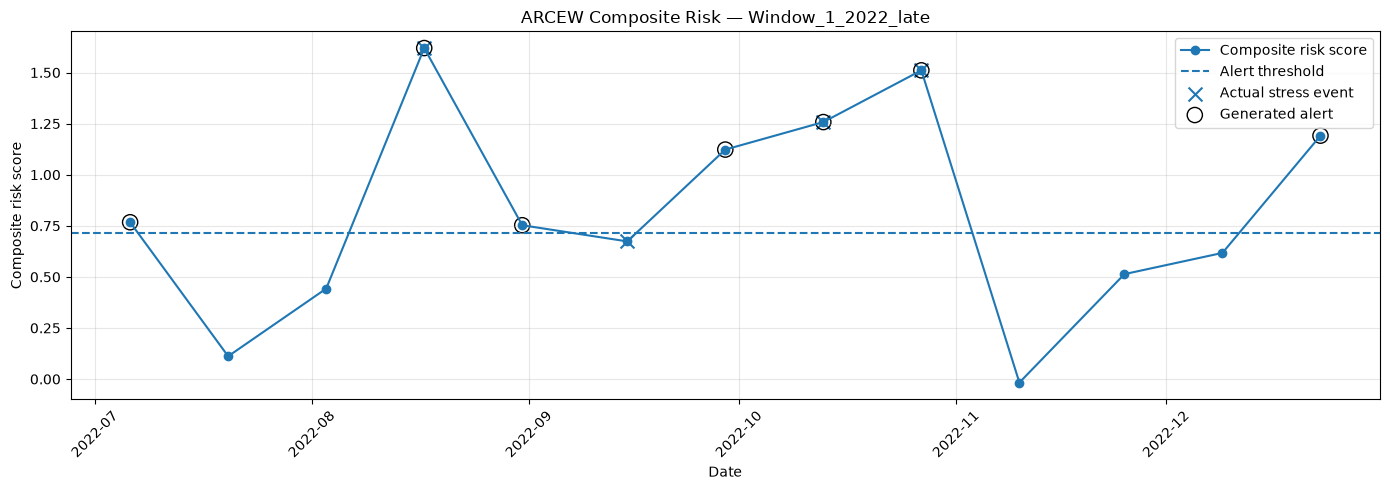

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\Window_1_2022_late_composite_risk_visualization.png


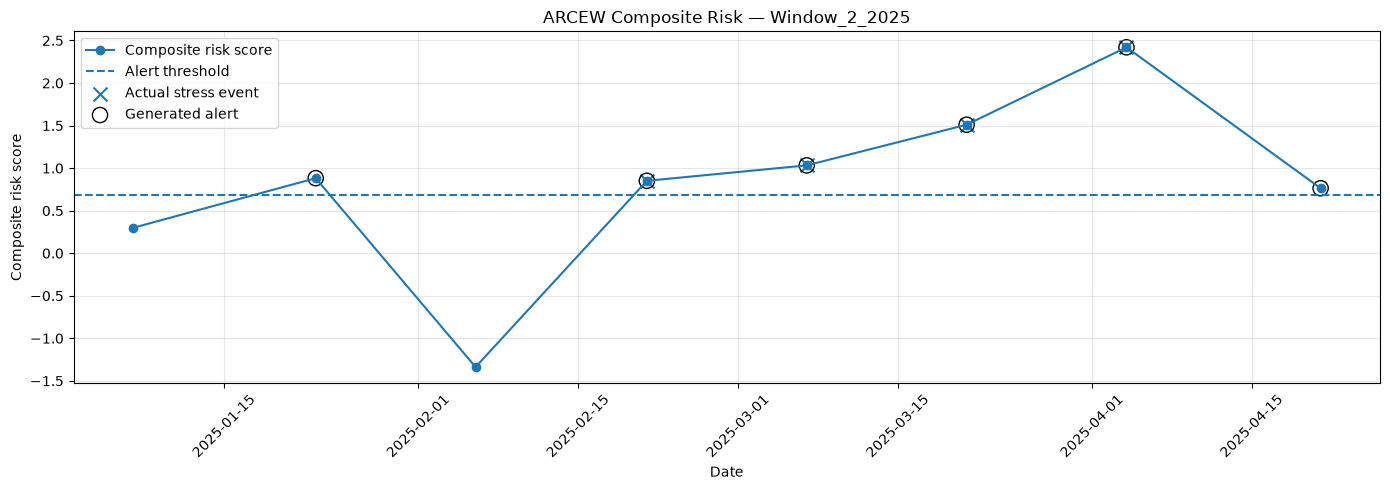

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\Window_2_2025_composite_risk_visualization.png


In [21]:
# Cell 21: Visualize composite risk scores and stress events

import matplotlib.pyplot as plt

for window in event_windows:

    window_alerts = explainable_alerts_df[
        explainable_alerts_df["window"] == window["name"]
    ].copy()

    if window_alerts.empty:
        continue

    window_alerts = window_alerts.sort_values("date")

    plt.figure(figsize=(14, 5))

    plt.plot(
        window_alerts["date"],
        window_alerts["composite_score"],
        marker="o",
        label="Composite risk score"
    )

    plt.axhline(
        window_alerts["threshold"].iloc[0],
        linestyle="--",
        label="Alert threshold"
    )

    stress_dates_window = window_alerts[
        window_alerts["actual_stress_event"] == 1
    ]

    plt.scatter(
        stress_dates_window["date"],
        stress_dates_window["composite_score"],
        marker="x",
        s=100,
        label="Actual stress event"
    )

    alert_dates_window = window_alerts[
        window_alerts["alert"] == 1
    ]

    plt.scatter(
        alert_dates_window["date"],
        alert_dates_window["composite_score"],
        facecolors="none",
        edgecolors="black",
        s=120,
        label="Generated alert"
    )

    plt.title(
        f"ARCEW Composite Risk — {window['name']}"
    )

    plt.xlabel("Date")
    plt.ylabel("Composite risk score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    output_path = (
        PHASE16_DIR /
        f"{window['name']}_composite_risk_visualization.png"
    )

    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Saved:", output_path)

In [22]:
# Cell 22: Quantify alert lead time relative to stress events

import pandas as pd
import numpy as np

# Obtain all known stress dates from the complete model dataset
all_stress_dates = sorted(
    pd.to_datetime(
        model_df.loc[
            model_df["date_stress_event"] == 1,
            "date"
        ]
    ).unique()
)

lead_time_records = []

for window in event_windows:

    window_alerts = explainable_alerts_df[
        explainable_alerts_df["window"] == window["name"]
    ].copy()

    if window_alerts.empty:
        continue

    window_alerts["date"] = pd.to_datetime(window_alerts["date"])

    for _, row in window_alerts.iterrows():

        alert_date = row["date"]

        # Find the first stress event on or after the alert date
        future_stress_dates = [
            stress_date
            for stress_date in all_stress_dates
            if stress_date >= alert_date
        ]

        if future_stress_dates:

            next_stress_date = future_stress_dates[0]
            lead_time_days = (
                next_stress_date - alert_date
            ).days

        else:

            next_stress_date = pd.NaT
            lead_time_days = np.nan

        if pd.isna(lead_time_days):
            timing_category = "No future stress event"

        elif lead_time_days == 0:
            timing_category = "Same-day detection"

        elif lead_time_days <= 7:
            timing_category = "1–7 days before"

        elif lead_time_days <= 30:
            timing_category = "8–30 days before"

        else:
            timing_category = "More than 30 days before"

        lead_time_records.append({
            "window": window["name"],
            "alert_date": alert_date,
            "composite_score": row["composite_score"],
            "actual_stress_event": row["actual_stress_event"],
            "alert": row["alert"],
            "next_stress_date": next_stress_date,
            "lead_time_days": lead_time_days,
            "timing_category": timing_category,
            "strongest_component": row["strongest_component"]
        })

lead_time_df = pd.DataFrame(lead_time_records)

lead_time_summary = (
    lead_time_df[
        lead_time_df["alert"] == 1
    ]
    .groupby(["window", "timing_category"])
    .size()
    .reset_index(name="alert_count")
)

print("Alert lead-time summary:")
display(lead_time_summary)

print("\nDetailed lead-time records:")
display(
    lead_time_df[
        lead_time_df["alert"] == 1
    ]
    .sort_values(["window", "alert_date"])
)

output_path = PHASE16_DIR / "alert_lead_time_analysis.csv"

lead_time_df.to_csv(output_path, index=False)

print("\nSaved:", output_path)

Alert lead-time summary:


,window,timing_category,alert_count
0,Window_1_2022_late,8–30 days before,2
1,Window_1_2022_late,More than 30 days before,2
2,Window_1_2022_late,Same-day detection,3
3,Window_2_2025,8–30 days before,1
4,Window_2_2025,No future stress event,1
5,Window_2_2025,Same-day detection,4



Detailed lead-time records:


,window,alert_date,composite_score,actual_stress_event,alert,next_stress_date,lead_time_days,timing_category,strongest_component
0,Window_1_2022_late,2022-07-06,0.767348,0,1,2022-08-17,42.0,More than 30 days before,systemic_risk_score_change
3,Window_1_2022_late,2022-08-17,1.619784,1,1,2022-08-17,0.0,Same-day detection,degree_change
4,Window_1_2022_late,2022-08-31,0.752783,0,1,2022-09-15,15.0,8–30 days before,betweenness_rolling_mean_3
6,Window_1_2022_late,2022-09-29,1.123033,0,1,2022-10-13,14.0,8–30 days before,degree_change
7,Window_1_2022_late,2022-10-13,1.257595,1,1,2022-10-13,0.0,Same-day detection,systemic_risk_score_change
8,Window_1_2022_late,2022-10-27,1.510722,1,1,2022-10-27,0.0,Same-day detection,systemic_risk_score_change
12,Window_1_2022_late,2022-12-23,1.191162,0,1,2025-02-21,791.0,More than 30 days before,systemic_risk_score_change
14,Window_2_2025,2025-01-23,0.881675,0,1,2025-02-21,29.0,8–30 days before,degree_change
16,Window_2_2025,2025-02-21,0.850957,1,1,2025-02-21,0.0,Same-day detection,betweenness_rolling_mean_3
17,Window_2_2025,2025-03-07,1.032114,1,1,2025-03-07,0.0,Same-day detection,betweenness_rolling_mean_3



Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\alert_lead_time_analysis.csv


In [23]:
# Cell 23: Evaluate early warnings within a fixed forecast horizon

FORECAST_HORIZON_DAYS = 30

bounded_records = []

for _, row in lead_time_df.iterrows():

    if row["alert"] != 1:
        continue

    lead_time = row["lead_time_days"]

    if pd.isna(lead_time):
        bounded_category = "No event within horizon"

    elif lead_time == 0:
        bounded_category = "Same-day detection"

    elif 0 < lead_time <= FORECAST_HORIZON_DAYS:
        bounded_category = "Valid early warning"

    else:
        bounded_category = "Outside forecast horizon"

    bounded_records.append({
        "window": row["window"],
        "alert_date": row["alert_date"],
        "composite_score": row["composite_score"],
        "actual_stress_event": row["actual_stress_event"],
        "next_stress_date": row["next_stress_date"],
        "lead_time_days": lead_time,
        "bounded_category": bounded_category,
        "strongest_component": row["strongest_component"]
    })

bounded_early_warning_df = pd.DataFrame(bounded_records)

summary = (
    bounded_early_warning_df
    .groupby(["window", "bounded_category"])
    .size()
    .reset_index(name="alert_count")
)

print("Bounded early-warning summary:")
display(summary)

print("\nDetailed bounded early-warning results:")
display(
    bounded_early_warning_df
    .sort_values(["window", "alert_date"])
)

output_path = PHASE16_DIR / "bounded_early_warning_analysis.csv"

bounded_early_warning_df.to_csv(output_path, index=False)

print("\nSaved:", output_path)

Bounded early-warning summary:


,window,bounded_category,alert_count
0,Window_1_2022_late,Outside forecast horizon,2
1,Window_1_2022_late,Same-day detection,3
2,Window_1_2022_late,Valid early warning,2
3,Window_2_2025,No event within horizon,1
4,Window_2_2025,Same-day detection,4
5,Window_2_2025,Valid early warning,1



Detailed bounded early-warning results:


,window,alert_date,composite_score,actual_stress_event,next_stress_date,lead_time_days,bounded_category,strongest_component
0,Window_1_2022_late,2022-07-06,0.767348,0,2022-08-17,42.0,Outside forecast horizon,systemic_risk_score_change
1,Window_1_2022_late,2022-08-17,1.619784,1,2022-08-17,0.0,Same-day detection,degree_change
2,Window_1_2022_late,2022-08-31,0.752783,0,2022-09-15,15.0,Valid early warning,betweenness_rolling_mean_3
3,Window_1_2022_late,2022-09-29,1.123033,0,2022-10-13,14.0,Valid early warning,degree_change
4,Window_1_2022_late,2022-10-13,1.257595,1,2022-10-13,0.0,Same-day detection,systemic_risk_score_change
5,Window_1_2022_late,2022-10-27,1.510722,1,2022-10-27,0.0,Same-day detection,systemic_risk_score_change
6,Window_1_2022_late,2022-12-23,1.191162,0,2025-02-21,791.0,Outside forecast horizon,systemic_risk_score_change
7,Window_2_2025,2025-01-23,0.881675,0,2025-02-21,29.0,Valid early warning,degree_change
8,Window_2_2025,2025-02-21,0.850957,1,2025-02-21,0.0,Same-day detection,betweenness_rolling_mean_3
9,Window_2_2025,2025-03-07,1.032114,1,2025-03-07,0.0,Same-day detection,betweenness_rolling_mean_3



Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\bounded_early_warning_analysis.csv


In [24]:
# Cell 24: Calculate distinct stress events covered by early warnings

valid_early_warnings = bounded_early_warning_df[
    bounded_early_warning_df["bounded_category"] == "Valid early warning"
].copy()

same_day_detections = bounded_early_warning_df[
    bounded_early_warning_df["bounded_category"] == "Same-day detection"
].copy()

# Count unique future stress events receiving advance warning
early_warning_event_summary = (
    valid_early_warnings
    .groupby("window")
    .agg(
        unique_events_covered=(
            "next_stress_date",
            "nunique"
        ),
        early_warning_alerts=(
            "alert_date",
            "count"
        ),
        average_lead_time_days=(
            "lead_time_days",
            "mean"
        ),
        maximum_lead_time_days=(
            "lead_time_days",
            "max"
        )
    )
    .reset_index()
)

# Count unique stress events detected on the same day
same_day_event_summary = (
    same_day_detections
    .groupby("window")
    .agg(
        same_day_events_detected=(
            "next_stress_date",
            "nunique"
        )
    )
    .reset_index()
)

event_coverage_summary = early_warning_event_summary.merge(
    same_day_event_summary,
    on="window",
    how="outer"
).fillna(0)

print("Event-level coverage summary:")
display(event_coverage_summary)

print("\nStress events receiving advance warning:")
display(
    valid_early_warnings[
        [
            "window",
            "next_stress_date",
            "alert_date",
            "lead_time_days",
            "strongest_component"
        ]
    ]
    .drop_duplicates(
        subset=["window", "next_stress_date"]
    )
    .sort_values(["window", "next_stress_date"])
)

output_path = PHASE16_DIR / "event_level_early_warning_coverage.csv"

event_coverage_summary.to_csv(
    output_path,
    index=False
)

print("\nSaved:", output_path)

Event-level coverage summary:


,window,unique_events_covered,early_warning_alerts,average_lead_time_days,maximum_lead_time_days,same_day_events_detected
0,Window_1_2022_late,2,2,14.5,15.0,3
1,Window_2_2025,1,1,29.0,29.0,4



Stress events receiving advance warning:


,window,next_stress_date,alert_date,lead_time_days,strongest_component
2,Window_1_2022_late,2022-09-15,2022-08-31,15.0,betweenness_rolling_mean_3
3,Window_1_2022_late,2022-10-13,2022-09-29,14.0,degree_change
7,Window_2_2025,2025-02-21,2025-01-23,29.0,degree_change



Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\event_level_early_warning_coverage.csv


In [25]:
# Cell 25: Create consolidated ARCEW performance summary

summary_records = []

for window in event_windows:

    window_name = window["name"]

    window_model = model_df[
        (model_df["date"] >= pd.to_datetime(window["validation_start"])) &
        (model_df["date"] <= pd.to_datetime(window["validation_end"]))
    ].copy()

    total_stress_events = int(
        window_model["date_stress_event"].sum()
    )

    window_bounded = bounded_early_warning_df[
        bounded_early_warning_df["window"] == window_name
    ].copy()

    valid_warnings = window_bounded[
        window_bounded["bounded_category"] == "Valid early warning"
    ]

    same_day = window_bounded[
        window_bounded["bounded_category"] == "Same-day detection"
    ]

    unique_advance_events = valid_warnings[
        "next_stress_date"
    ].nunique()

    unique_same_day_events = same_day[
        "next_stress_date"
    ].nunique()

    average_lead_time = (
        valid_warnings["lead_time_days"].mean()
        if not valid_warnings.empty
        else np.nan
    )

    summary_records.append({
        "window": window_name,
        "total_stress_events": total_stress_events,
        "advance_warning_events": unique_advance_events,
        "advance_warning_coverage": (
            unique_advance_events / total_stress_events
            if total_stress_events > 0
            else np.nan
        ),
        "same_day_events_detected": unique_same_day_events,
        "same_day_detection_coverage": (
            unique_same_day_events / total_stress_events
            if total_stress_events > 0
            else np.nan
        ),
        "average_lead_time_days": average_lead_time,
        "early_warning_alert_count": len(valid_warnings)
    })

arcew_performance_summary = pd.DataFrame(summary_records)

print("ARCEW Performance Summary:")
display(arcew_performance_summary)

output_path = PHASE16_DIR / "arcew_performance_summary.csv"

arcew_performance_summary.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

ARCEW Performance Summary:


,window,total_stress_events,advance_warning_events,advance_warning_coverage,same_day_events_detected,same_day_detection_coverage,average_lead_time_days,early_warning_alert_count
0,Window_1_2022_late,4,2,0.50,3,0.75,14.5,2
1,Window_2_2025,4,1,0.25,4,1.00,29.0,1


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\arcew_performance_summary.csv


In [26]:
# Cell 26: Nested walk-forward feature selection

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

candidate_features = temporal_features.copy()

nested_results = []

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.to_datetime(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.to_datetime(window["validation_start"])) &
        (model_df["date"] <= pd.to_datetime(window["validation_end"]))
    ].copy()

    if validation_data["date_stress_event"].nunique() < 2:
        print(f"Skipping {window['name']}: insufficient validation classes")
        continue

    # Select features using training data only
    feature_scores = []

    for feature in candidate_features:

        train_feature = train_data[[feature, "date_stress_event"]].dropna()

        if train_feature[feature].nunique() < 2:
            continue

        normal_scores = train_feature.loc[
            train_feature["date_stress_event"] == 0,
            feature
        ]

        stress_scores = train_feature.loc[
            train_feature["date_stress_event"] == 1,
            feature
        ]

        if normal_scores.empty or stress_scores.empty:
            continue

        difference = abs(
            stress_scores.mean() - normal_scores.mean()
        )

        feature_scores.append({
            "feature": feature,
            "mean_difference": difference
        })

    feature_scores_df = (
        pd.DataFrame(feature_scores)
        .sort_values("mean_difference", ascending=False)
    )

    selected_features = feature_scores_df.head(4)["feature"].tolist()

    # Standardize using training statistics only
    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train_data[selected_features]
    )

    X_validation = scaler.transform(
        validation_data[selected_features]
    )

    y_train = train_data["date_stress_event"].values
    y_validation = validation_data["date_stress_event"].values

    # Equal-weight composite
    train_composite = X_train.mean(axis=1)
    validation_composite = X_validation.mean(axis=1)

    # Select score direction using training data only
    normal_auc = roc_auc_score(
        y_train,
        train_composite
    )

    reversed_auc = roc_auc_score(
        y_train,
        -train_composite
    )

    if reversed_auc > normal_auc:
        validation_composite = -validation_composite
        selected_direction = "reversed"
    else:
        selected_direction = "normal"

    validation_roc = roc_auc_score(
        y_validation,
        validation_composite
    )

    validation_pr = average_precision_score(
        y_validation,
        validation_composite
    )

    nested_results.append({
        "window": window["name"],
        "selected_features": ", ".join(selected_features),
        "direction": selected_direction,
        "validation_roc_auc": validation_roc,
        "validation_pr_auc": validation_pr
    })

nested_results_df = pd.DataFrame(nested_results)

display(nested_results_df)

output_path = PHASE16_DIR / "nested_walkforward_feature_selection.csv"

nested_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,selected_features,direction,validation_roc_auc,validation_pr_auc
0,Window_1_2022_late,"risk_percentile_rolling_std_3, risk_percentile...",reversed,0.666667,0.582143
1,Window_2_2025,"risk_percentile_rolling_mean_3, risk_percentil...",normal,0.687500,0.733333


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\nested_walkforward_feature_selection.csv


In [27]:
# Cell 27: Compare original, composite, and nested evaluations

comparison_records = [
    {
        "evaluation": "Reversed PageRank baseline",
        "mean_roc_auc": 0.666667,
        "mean_pr_auc": 0.283965
    },
    {
        "evaluation": "Earlier composite signal",
        "mean_roc_auc": 0.913194,
        "mean_pr_auc": 0.912500
    },
    {
        "evaluation": "Nested walk-forward selection",
        "mean_roc_auc": nested_results_df[
            "validation_roc_auc"
        ].mean(),
        "mean_pr_auc": nested_results_df[
            "validation_pr_auc"
        ].mean()
    }
]

evaluation_comparison_df = pd.DataFrame(comparison_records)

display(evaluation_comparison_df)

output_path = PHASE16_DIR / "evaluation_method_comparison.csv"

evaluation_comparison_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,evaluation,mean_roc_auc,mean_pr_auc
0,Reversed PageRank baseline,0.666667,0.283965
1,Earlier composite signal,0.913194,0.912500
2,Nested walk-forward selection,0.677083,0.657738


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\evaluation_method_comparison.csv


In [28]:
# Cell 28: Multi-horizon nested walk-forward evaluation

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

FORECAST_HORIZONS = [7, 14, 30, 60]

multi_horizon_results = []

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.to_datetime(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.to_datetime(window["validation_start"])) &
        (model_df["date"] <= pd.to_datetime(window["validation_end"]))
    ].copy()

    train_dates = train_data["date"].values
    validation_dates = validation_data["date"].values

    for horizon in FORECAST_HORIZONS:

        # Create horizon-specific labels using future stress dates
        def create_horizon_labels(data):

            labels = []

            for current_date in data["date"]:

                future_stress = [
                    stress_date
                    for stress_date in all_stress_dates
                    if (
                        current_date < stress_date
                        and
                        (stress_date - current_date).days <= horizon
                    )
                ]

                labels.append(
                    int(len(future_stress) > 0)
                )

            return np.array(labels)

        y_train = create_horizon_labels(train_data)
        y_validation = create_horizon_labels(validation_data)

        # Skip cases without both classes
        if len(np.unique(y_train)) < 2:
            continue

        if len(np.unique(y_validation)) < 2:
            continue

        # Select features using training data only
        feature_scores = []

        for feature in candidate_features:

            train_feature = train_data[
                [feature]
            ].copy()

            normal_values = train_feature.loc[
                y_train == 0,
                feature
            ]

            stress_values = train_feature.loc[
                y_train == 1,
                feature
            ]

            if normal_values.empty or stress_values.empty:
                continue

            difference = abs(
                stress_values.mean() - normal_values.mean()
            )

            feature_scores.append({
                "feature": feature,
                "mean_difference": difference
            })

        if not feature_scores:
            continue

        feature_scores_df = (
            pd.DataFrame(feature_scores)
            .sort_values(
                "mean_difference",
                ascending=False
            )
        )

        selected_features = feature_scores_df.head(4)[
            "feature"
        ].tolist()

        # Training-only scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            train_data[selected_features]
        )

        X_validation = scaler.transform(
            validation_data[selected_features]
        )

        train_score = X_train.mean(axis=1)
        validation_score = X_validation.mean(axis=1)

        # Training-only direction selection
        normal_auc = roc_auc_score(
            y_train,
            train_score
        )

        reversed_auc = roc_auc_score(
            y_train,
            -train_score
        )

        if reversed_auc > normal_auc:

            validation_score = -validation_score
            direction = "reversed"

        else:

            direction = "normal"

        validation_roc_auc = roc_auc_score(
            y_validation,
            validation_score
        )

        validation_pr_auc = average_precision_score(
            y_validation,
            validation_score
        )

        multi_horizon_results.append({
            "window": window["name"],
            "horizon_days": horizon,
            "selected_features": ", ".join(selected_features),
            "direction": direction,
            "train_positive_count": int(y_train.sum()),
            "validation_positive_count": int(y_validation.sum()),
            "validation_roc_auc": validation_roc_auc,
            "validation_pr_auc": validation_pr_auc
        })

multi_horizon_results_df = pd.DataFrame(
    multi_horizon_results
)

display(multi_horizon_results_df)

output_path = (
    PHASE16_DIR /
    "multi_horizon_nested_walkforward_results.csv"
)

multi_horizon_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,horizon_days,selected_features,direction,train_positive_count,validation_positive_count,validation_roc_auc,validation_pr_auc
0,Window_1_2022_late,14,"risk_percentile_rolling_mean_3, risk_percentil...",normal,3,3,0.400000,0.268687
1,Window_1_2022_late,30,"risk_percentile_rolling_mean_3, pagerank_zscor...",normal,6,7,0.523810,0.627417
2,Window_1_2022_late,60,"risk_percentile_rolling_mean_3, betweenness_zs...",normal,10,8,0.650000,0.703175
3,Window_2_2025,14,"risk_percentile_rolling_mean_3, risk_percentil...",normal,6,3,0.466667,0.411111
4,Window_2_2025,30,"risk_percentile_rolling_mean_3, risk_percentil...",normal,13,5,0.133333,0.505952
5,Window_2_2025,60,"risk_percentile_rolling_mean_3, risk_percentil...",normal,18,6,0.000000,0.594048


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\multi_horizon_nested_walkforward_results.csv


In [29]:
# Cell 29: Summarize performance and stability by forecast horizon

horizon_summary = (
    multi_horizon_results_df
    .groupby("horizon_days")
    .agg(
        evaluation_windows=("window", "nunique"),
        mean_roc_auc=("validation_roc_auc", "mean"),
        min_roc_auc=("validation_roc_auc", "min"),
        max_roc_auc=("validation_roc_auc", "max"),
        mean_pr_auc=("validation_pr_auc", "mean"),
        min_pr_auc=("validation_pr_auc", "min"),
        max_pr_auc=("validation_pr_auc", "max"),
        total_validation_positives=(
            "validation_positive_count",
            "sum"
        )
    )
    .reset_index()
    .sort_values("horizon_days")
)

print("Forecast horizon stability summary:")
display(horizon_summary)

output_path = (
    PHASE16_DIR /
    "forecast_horizon_stability_summary.csv"
)

horizon_summary.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Forecast horizon stability summary:


,horizon_days,evaluation_windows,mean_roc_auc,min_roc_auc,max_roc_auc,mean_pr_auc,min_pr_auc,max_pr_auc,total_validation_positives
0,14,2,0.433333,0.400000,0.466667,0.339899,0.268687,0.411111,6
1,30,2,0.328571,0.133333,0.523810,0.566685,0.505952,0.627417,12
2,60,2,0.325000,0.000000,0.650000,0.648611,0.594048,0.703175,14


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\forecast_horizon_stability_summary.csv


In [30]:
# Cell 30: Validate forecast-horizon target construction

horizon_label_summary = []

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.to_datetime(window["train_end"])
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= pd.to_datetime(window["validation_start"])) &
        (model_df["date"] <= pd.to_datetime(window["validation_end"]))
    ].copy()

    for horizon in FORECAST_HORIZONS:

        def create_horizon_labels_checked(data):

            labels = []

            for current_date in data["date"]:

                future_stress = [
                    stress_date
                    for stress_date in all_stress_dates
                    if (
                        current_date < stress_date
                        and
                        (stress_date - current_date).days <= horizon
                    )
                ]

                labels.append(int(len(future_stress) > 0))

            return np.array(labels)

        train_labels = create_horizon_labels_checked(train_data)
        validation_labels = create_horizon_labels_checked(
            validation_data
        )

        horizon_label_summary.append({
            "window": window["name"],
            "horizon_days": horizon,
            "train_observations": len(train_labels),
            "train_positive_count": int(train_labels.sum()),
            "train_positive_rate": train_labels.mean(),
            "validation_observations": len(validation_labels),
            "validation_positive_count": int(validation_labels.sum()),
            "validation_positive_rate": validation_labels.mean()
        })

horizon_label_summary_df = pd.DataFrame(
    horizon_label_summary
)

display(horizon_label_summary_df)

output_path = (
    PHASE16_DIR /
    "horizon_label_distribution_validation.csv"
)

horizon_label_summary_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,horizon_days,train_observations,train_positive_count,train_positive_rate,validation_observations,validation_positive_count,validation_positive_rate
0,Window_1_2022_late,7,11,0,0.000000,13,0,0.000000
1,Window_1_2022_late,14,11,3,0.272727,13,3,0.230769
2,Window_1_2022_late,30,11,6,0.545455,13,7,0.538462
3,Window_1_2022_late,60,11,10,0.909091,13,8,0.615385
4,Window_2_2025,7,73,0,0.000000,8,0,0.000000
5,Window_2_2025,14,73,6,0.082192,8,3,0.375000
6,Window_2_2025,30,73,13,0.178082,8,5,0.625000
7,Window_2_2025,60,73,18,0.246575,8,6,0.750000


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\horizon_label_distribution_validation.csv


In [31]:
# Cell 31: Analyze observation gaps and stress-event spacing

date_gap_df = model_df[["date", "date_stress_event"]].copy()

date_gap_df["date_gap_days"] = (
    date_gap_df["date"].diff().dt.days
)

print("Observation gap statistics:")
display(
    date_gap_df["date_gap_days"].describe()
)

print("\nObservation gap distribution:")
display(
    date_gap_df["date_gap_days"]
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nStress-event dates and previous observation gaps:")

stress_gap_df = date_gap_df[
    date_gap_df["date_stress_event"] == 1
].copy()

display(
    stress_gap_df[
        ["date", "date_gap_days"]
    ]
)

output_path = (
    PHASE16_DIR /
    "observation_gap_analysis.csv"
)

date_gap_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Observation gap statistics:


count    102.000000
mean      16.284314
std        6.682884
min       14.000000
25%       14.000000
50%       14.000000
75%       15.000000
max       45.000000
Name: date_gap_days, dtype: float64


Observation gap distribution:


date_gap_days
14.0    60
15.0    26
16.0     2
17.0     4
18.0     3
28.0     1
29.0     1
43.0     2
44.0     1
45.0     2
Name: count, dtype: int64


Stress-event dates and previous observation gaps:


,date,date_gap_days
0,2021-12-28,NaN
1,2022-02-09,43.0
5,2022-04-07,14.0
6,2022-04-22,15.0
7,2022-05-06,14.0
8,2022-05-20,14.0
9,2022-06-06,17.0
14,2022-08-17,14.0
16,2022-09-15,15.0
18,2022-10-13,14.0


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\observation_gap_analysis.csv


In [32]:
# Cell 32: Create observation-based forecast labels

OBSERVATION_HORIZONS = [1, 2, 3, 4]

observation_horizon_results = []

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.to_datetime(window["train_end"])
    ].copy().reset_index(drop=True)

    validation_data = model_df[
        (model_df["date"] >= pd.to_datetime(window["validation_start"])) &
        (model_df["date"] <= pd.to_datetime(window["validation_end"]))
    ].copy().reset_index(drop=True)

    for horizon in OBSERVATION_HORIZONS:

        def create_observation_labels(data, horizon):

            labels = []

            for i in range(len(data)):

                future_rows = data.iloc[
                    i + 1 : i + horizon + 1
                ]

                label = int(
                    future_rows["date_stress_event"].sum() > 0
                )

                labels.append(label)

            return np.array(labels)

        y_train = create_observation_labels(
            train_data,
            horizon
        )

        y_validation = create_observation_labels(
            validation_data,
            horizon
        )

        observation_horizon_results.append({
            "window": window["name"],
            "observation_horizon": horizon,
            "train_observations": len(y_train),
            "train_positive_count": int(y_train.sum()),
            "train_positive_rate": y_train.mean(),
            "validation_observations": len(y_validation),
            "validation_positive_count": int(y_validation.sum()),
            "validation_positive_rate": y_validation.mean()
        })

observation_horizon_results_df = pd.DataFrame(
    observation_horizon_results
)

display(observation_horizon_results_df)

output_path = (
    PHASE16_DIR /
    "observation_based_horizon_labels.csv"
)

observation_horizon_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,observation_horizon,train_observations,train_positive_count,train_positive_rate,validation_observations,validation_positive_count,validation_positive_rate
0,Window_1_2022_late,1,11,6,0.545455,13,4,0.307692
1,Window_1_2022_late,2,11,7,0.636364,13,7,0.538462
2,Window_1_2022_late,3,11,8,0.727273,13,8,0.615385
3,Window_1_2022_late,4,11,9,0.818182,13,8,0.615385
4,Window_2_2025,1,73,10,0.136986,8,4,0.500000
5,Window_2_2025,2,73,14,0.191781,8,5,0.625000
6,Window_2_2025,3,73,16,0.219178,8,6,0.750000
7,Window_2_2025,4,73,18,0.246575,8,6,0.750000


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\observation_based_horizon_labels.csv


In [33]:
# Cell 33: Nested walk-forward evaluation with observation horizons

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

observation_nested_results = []

for window in event_windows:

    train_data = model_df[
        model_df["date"] <= pd.to_datetime(window["train_end"])
    ].copy().reset_index(drop=True)

    validation_data = model_df[
        (model_df["date"] >= pd.to_datetime(window["validation_start"])) &
        (model_df["date"] <= pd.to_datetime(window["validation_end"]))
    ].copy().reset_index(drop=True)

    for horizon in OBSERVATION_HORIZONS:

        def create_observation_labels(data, horizon):

            labels = []

            for i in range(len(data)):

                future_rows = data.iloc[
                    i + 1 : i + horizon + 1
                ]

                labels.append(
                    int(
                        future_rows["date_stress_event"].sum() > 0
                    )
                )

            return np.array(labels)

        y_train = create_observation_labels(
            train_data,
            horizon
        )

        y_validation = create_observation_labels(
            validation_data,
            horizon
        )

        if len(np.unique(y_train)) < 2:
            continue

        if len(np.unique(y_validation)) < 2:
            continue

        feature_scores = []

        for feature in candidate_features:

            normal_values = train_data.loc[
                y_train == 0,
                feature
            ]

            stress_values = train_data.loc[
                y_train == 1,
                feature
            ]

            if normal_values.empty or stress_values.empty:
                continue

            difference = abs(
                stress_values.mean() - normal_values.mean()
            )

            feature_scores.append({
                "feature": feature,
                "mean_difference": difference
            })

        feature_scores_df = (
            pd.DataFrame(feature_scores)
            .sort_values(
                "mean_difference",
                ascending=False
            )
        )

        selected_features = feature_scores_df.head(4)[
            "feature"
        ].tolist()

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            train_data[selected_features]
        )

        X_validation = scaler.transform(
            validation_data[selected_features]
        )

        train_score = X_train.mean(axis=1)
        validation_score = X_validation.mean(axis=1)

        normal_auc = roc_auc_score(
            y_train,
            train_score
        )

        reversed_auc = roc_auc_score(
            y_train,
            -train_score
        )

        if reversed_auc > normal_auc:
            validation_score = -validation_score
            direction = "reversed"
        else:
            direction = "normal"

        validation_roc_auc = roc_auc_score(
            y_validation,
            validation_score
        )

        validation_pr_auc = average_precision_score(
            y_validation,
            validation_score
        )

        observation_nested_results.append({
            "window": window["name"],
            "observation_horizon": horizon,
            "selected_features": ", ".join(selected_features),
            "direction": direction,
            "train_positive_count": int(y_train.sum()),
            "validation_positive_count": int(y_validation.sum()),
            "validation_roc_auc": validation_roc_auc,
            "validation_pr_auc": validation_pr_auc
        })

observation_nested_results_df = pd.DataFrame(
    observation_nested_results
)

display(observation_nested_results_df)

output_path = (
    PHASE16_DIR /
    "observation_horizon_nested_evaluation.csv"
)

observation_nested_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,observation_horizon,selected_features,direction,train_positive_count,validation_positive_count,validation_roc_auc,validation_pr_auc
0,Window_1_2022_late,1,"risk_percentile_rolling_std_3, multi_signal_ri...",normal,6,4,0.444444,0.331845
1,Window_1_2022_late,2,"risk_percentile_rolling_mean_3, pagerank_zscor...",normal,7,7,0.690476,0.821970
2,Window_1_2022_late,3,"risk_percentile_rolling_mean_3, risk_percentil...",normal,8,8,0.725000,0.860795
3,Window_1_2022_late,4,"risk_percentile_rolling_mean_3, betweenness_zs...",normal,9,8,0.650000,0.703175
4,Window_2_2025,1,"risk_percentile_rolling_mean_3, risk_percentil...",normal,10,4,0.250000,0.433333
5,Window_2_2025,2,"risk_percentile_rolling_mean_3, risk_percentil...",normal,14,5,0.266667,0.545000
6,Window_2_2025,3,"risk_percentile_rolling_mean_3, risk_percentil...",normal,16,6,0.000000,0.594048
7,Window_2_2025,4,"risk_percentile_rolling_mean_3, risk_percentil...",normal,18,6,0.000000,0.594048


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\observation_horizon_nested_evaluation.csv


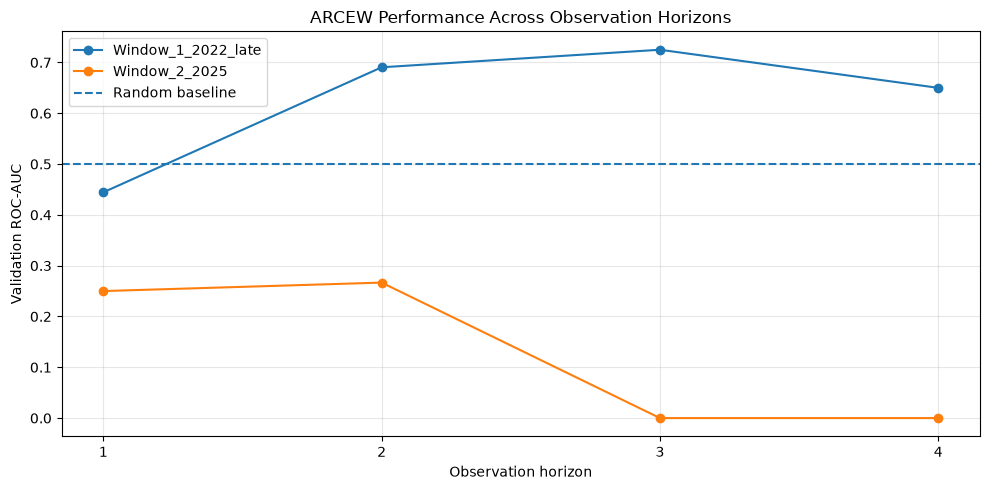

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\observation_horizon_performance.png


In [34]:
# Cell 34: Visualize observation-horizon performance

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for window_name in observation_nested_results_df["window"].unique():

    window_data = observation_nested_results_df[
        observation_nested_results_df["window"] == window_name
    ].sort_values("observation_horizon")

    plt.plot(
        window_data["observation_horizon"],
        window_data["validation_roc_auc"],
        marker="o",
        label=window_name
    )

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("Observation horizon")
plt.ylabel("Validation ROC-AUC")
plt.title("ARCEW Performance Across Observation Horizons")
plt.xticks(OBSERVATION_HORIZONS)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

output_path = (
    PHASE16_DIR /
    "observation_horizon_performance.png"
)

plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)

In [35]:
# Cell 34: Corrected observation-horizon nested evaluation

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

corrected_observation_results = []

# Work on the complete chronological dataset
full_data = model_df.sort_values("date").reset_index(drop=True).copy()

# Create complete future-observation labels
for horizon in OBSERVATION_HORIZONS:

    labels = []

    for i in range(len(full_data)):

        future_rows = full_data.iloc[
            i + 1 : i + horizon + 1
        ]

        # Require a complete future horizon
        if len(future_rows) < horizon:
            labels.append(np.nan)
        else:
            labels.append(
                int(
                    future_rows["date_stress_event"].sum() > 0
                )
            )

    full_data[f"target_{horizon}obs"] = labels


for window in event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(window["validation_start"])
    validation_end = pd.to_datetime(window["validation_end"])

    for horizon in OBSERVATION_HORIZONS:

        target_column = f"target_{horizon}obs"

        # Training observations must have their complete
        # future horizon before or on the training cutoff
        train_data = full_data[
            (
                full_data["date"] <= train_end
            )
            &
            (
                full_data["date"].shift(-horizon) <= train_end
            )
            &
            (
                full_data[target_column].notna()
            )
        ].copy()

        # Validation labels use the complete future dataset
        validation_data = full_data[
            (
                full_data["date"] >= validation_start
            )
            &
            (
                full_data["date"] <= validation_end
            )
            &
            (
                full_data[target_column].notna()
            )
        ].copy()

        if len(train_data) < 10 or len(validation_data) < 5:
            continue

        y_train = train_data[target_column].astype(int).values
        y_validation = (
            validation_data[target_column].astype(int).values
        )

        if len(np.unique(y_train)) < 2:
            continue

        if len(np.unique(y_validation)) < 2:
            continue

        # Select features using training data only
        feature_scores = []

        for feature in candidate_features:

            normal_values = train_data.loc[
                y_train == 0,
                feature
            ]

            stress_values = train_data.loc[
                y_train == 1,
                feature
            ]

            if normal_values.empty or stress_values.empty:
                continue

            difference = abs(
                stress_values.mean() - normal_values.mean()
            )

            feature_scores.append({
                "feature": feature,
                "mean_difference": difference
            })

        feature_scores_df = (
            pd.DataFrame(feature_scores)
            .sort_values(
                "mean_difference",
                ascending=False
            )
        )

        selected_features = feature_scores_df.head(4)[
            "feature"
        ].tolist()

        if len(selected_features) == 0:
            continue

        # Training-only standardization
        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            train_data[selected_features]
        )

        X_validation = scaler.transform(
            validation_data[selected_features]
        )

        train_score = X_train.mean(axis=1)
        validation_score = X_validation.mean(axis=1)

        # Select direction using training data only
        normal_auc = roc_auc_score(
            y_train,
            train_score
        )

        reversed_auc = roc_auc_score(
            y_train,
            -train_score
        )

        if reversed_auc > normal_auc:
            validation_score = -validation_score
            direction = "reversed"
        else:
            direction = "normal"

        validation_roc_auc = roc_auc_score(
            y_validation,
            validation_score
        )

        validation_pr_auc = average_precision_score(
            y_validation,
            validation_score
        )

        corrected_observation_results.append({
            "window": window["name"],
            "observation_horizon": horizon,
            "selected_features": ", ".join(
                selected_features
            ),
            "direction": direction,
            "train_observation_count": len(train_data),
            "validation_observation_count": len(
                validation_data
            ),
            "train_positive_count": int(y_train.sum()),
            "validation_positive_count": int(
                y_validation.sum()
            ),
            "validation_roc_auc": validation_roc_auc,
            "validation_pr_auc": validation_pr_auc
        })


corrected_results_df = pd.DataFrame(
    corrected_observation_results
)

display(corrected_results_df)

output_path = (
    PHASE16_DIR /
    "corrected_observation_horizon_evaluation.csv"
)

corrected_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,observation_horizon,selected_features,direction,train_observation_count,validation_observation_count,train_positive_count,validation_positive_count,validation_roc_auc,validation_pr_auc
0,Window_1_2022_late,1,"risk_percentile_rolling_mean_3, risk_percentil...",normal,10,13,6,4,0.500000,0.357143
1,Window_2_2025,1,"risk_percentile_rolling_mean_3, risk_percentil...",normal,72,8,10,4,0.250000,0.433333
2,Window_2_2025,2,"risk_percentile_rolling_mean_3, risk_percentil...",normal,71,8,14,5,0.266667,0.545000
3,Window_2_2025,3,"risk_percentile_rolling_mean_3, risk_percentil...",normal,70,8,16,6,0.000000,0.594048
4,Window_2_2025,4,"risk_percentile_rolling_mean_3, risk_percentil...",normal,69,8,18,6,0.000000,0.594048


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\corrected_observation_horizon_evaluation.csv


In [36]:
# Cell 35: Compare network and risk characteristics across stress periods

regime_comparison = []

for window in event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(window["validation_start"])
    validation_end = pd.to_datetime(window["validation_end"])

    window_data = model_df[
        (model_df["date"] >= validation_start) &
        (model_df["date"] <= validation_end)
    ].copy()

    if window_data.empty:
        continue

    stress_data = window_data[
        window_data["date_stress_event"] == 1
    ]

    normal_data = window_data[
        window_data["date_stress_event"] == 0
    ]

    for feature in signal_columns:

        stress_mean = stress_data[feature].mean()
        normal_mean = normal_data[feature].mean()

        regime_comparison.append({
            "window": window["name"],
            "feature": feature,
            "stress_mean": stress_mean,
            "normal_mean": normal_mean,
            "mean_difference": stress_mean - normal_mean,
            "stress_observations": len(stress_data),
            "normal_observations": len(normal_data)
        })

regime_comparison_df = pd.DataFrame(
    regime_comparison
)

display(
    regime_comparison_df.sort_values(
        ["window", "feature"]
    )
)

output_path = (
    PHASE16_DIR /
    "regime_signal_comparison.csv"
)

regime_comparison_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,feature,stress_mean,normal_mean,mean_difference,stress_observations,normal_observations
1,Window_1_2022_late,betweenness,0.538146,0.540866,-0.002720,4,9
0,Window_1_2022_late,degree,0.865115,0.864468,0.000647,4,9
4,Window_1_2022_late,multi_signal_risk_score,0.684742,0.685912,-0.001170,4,9
2,Window_1_2022_late,pagerank,0.491333,0.491769,-0.000435,4,9
5,Window_1_2022_late,risk_percentile,75.001042,74.954167,0.046875,4,9
3,Window_1_2022_late,systemic_risk_score,0.844375,0.846546,-0.002171,4,9
7,Window_2_2025,betweenness,0.531240,0.477698,0.053542,4,4
6,Window_2_2025,degree,0.510698,0.533687,-0.022990,4,4
10,Window_2_2025,multi_signal_risk_score,0.501906,0.503820,-0.001914,4,4
8,Window_2_2025,pagerank,0.474187,0.495458,-0.021271,4,4


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\regime_signal_comparison.csv


In [37]:
# Cell 36: Analyze regime-dependent signal direction

direction_analysis = []

for window_name in regime_comparison_df["window"].unique():

    window_data = regime_comparison_df[
        regime_comparison_df["window"] == window_name
    ].copy()

    for _, row in window_data.iterrows():

        difference = row["mean_difference"]

        if difference > 0:
            direction = "Higher during stress"
        elif difference < 0:
            direction = "Lower during stress"
        else:
            direction = "No difference"

        direction_analysis.append({
            "window": window_name,
            "feature": row["feature"],
            "mean_difference": difference,
            "direction": direction,
            "absolute_difference": abs(difference)
        })

direction_analysis_df = pd.DataFrame(
    direction_analysis
)

display(
    direction_analysis_df.sort_values(
        ["feature", "window"]
    )
)

# Compare direction changes between windows

direction_pivot = direction_analysis_df.pivot(
    index="feature",
    columns="window",
    values="mean_difference"
)

direction_pivot["direction_change"] = (
    np.sign(
        direction_pivot.iloc[:, 0]
    )
    !=
    np.sign(
        direction_pivot.iloc[:, 1]
    )
)

display(direction_pivot)

output_path = (
    PHASE16_DIR /
    "regime_dependent_signal_direction.csv"
)

direction_analysis_df.to_csv(
    output_path,
    index=False
)

direction_pivot.to_csv(
    PHASE16_DIR /
    "regime_signal_direction_pivot.csv"
)

print("Saved:", output_path)

,window,feature,mean_difference,direction,absolute_difference
1,Window_1_2022_late,betweenness,-0.002720,Lower during stress,0.002720
7,Window_2_2025,betweenness,0.053542,Higher during stress,0.053542
0,Window_1_2022_late,degree,0.000647,Higher during stress,0.000647
6,Window_2_2025,degree,-0.022990,Lower during stress,0.022990
4,Window_1_2022_late,multi_signal_risk_score,-0.001170,Lower during stress,0.001170
10,Window_2_2025,multi_signal_risk_score,-0.001914,Lower during stress,0.001914
2,Window_1_2022_late,pagerank,-0.000435,Lower during stress,0.000435
8,Window_2_2025,pagerank,-0.021271,Lower during stress,0.021271
5,Window_1_2022_late,risk_percentile,0.046875,Higher during stress,0.046875
11,Window_2_2025,risk_percentile,-2.373958,Lower during stress,2.373958


window,Window_1_2022_late,Window_2_2025,direction_change
feature,,,
betweenness,-0.002720,0.053542,True
degree,0.000647,-0.022990,True
multi_signal_risk_score,-0.001170,-0.001914,False
pagerank,-0.000435,-0.021271,False
risk_percentile,0.046875,-2.373958,True
systemic_risk_score,-0.002171,-0.016937,False


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\regime_dependent_signal_direction.csv


In [38]:
# Cell 37: Quantify regime-dependent signal instability

instability_records = []

for feature in direction_pivot.index:

    window_2022_difference = direction_pivot.loc[
        feature,
        "Window_1_2022_late"
    ]

    window_2025_difference = direction_pivot.loc[
        feature,
        "Window_2_2025"
    ]

    direction_changed = (
        np.sign(window_2022_difference)
        !=
        np.sign(window_2025_difference)
    )

    relative_change = (
        abs(window_2025_difference)
        -
        abs(window_2022_difference)
    )

    instability_records.append({
        "feature": feature,
        "window_2022_difference": window_2022_difference,
        "window_2025_difference": window_2025_difference,
        "direction_changed": direction_changed,
        "absolute_difference_change": relative_change
    })

instability_df = pd.DataFrame(
    instability_records
)

instability_df = instability_df.sort_values(
    "direction_changed",
    ascending=False
)

display(instability_df)

output_path = (
    PHASE16_DIR /
    "regime_signal_instability_analysis.csv"
)

instability_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,feature,window_2022_difference,window_2025_difference,direction_changed,absolute_difference_change
0,betweenness,-0.002720,0.053542,True,0.050822
1,degree,0.000647,-0.022990,True,0.022343
4,risk_percentile,0.046875,-2.373958,True,2.327083
2,multi_signal_risk_score,-0.001170,-0.001914,False,0.000744
3,pagerank,-0.000435,-0.021271,False,0.020836
5,systemic_risk_score,-0.002171,-0.016937,False,0.014766


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\regime_signal_instability_analysis.csv


In [39]:
# Cell 38: Adaptive Regime-Aware Weighting

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

adaptive_results = []
adaptive_scores_all = []

adaptive_features = [
    "betweenness_change",
    "degree_change",
    "risk_percentile_change",
    "systemic_risk_score_change",
    "multi_signal_risk_score_change",
    "pagerank_change"
]

for window in event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(window["validation_start"])
    validation_end = pd.to_datetime(window["validation_end"])

    train_data = model_df[
        model_df["date"] <= train_end
    ].copy()

    validation_data = model_df[
        (model_df["date"] >= validation_start) &
        (model_df["date"] <= validation_end)
    ].copy()

    if train_data.empty or validation_data.empty:
        continue

    # Define regime using training-period systemic-risk volatility
    regime_metric = "systemic_risk_score_rolling_std_3"

    regime_threshold = train_data[
        regime_metric
    ].median()

    train_data["regime"] = np.where(
        train_data[regime_metric] >= regime_threshold,
        "high_volatility",
        "low_volatility"
    )

    validation_data["regime"] = np.where(
        validation_data[regime_metric] >= regime_threshold,
        "high_volatility",
        "low_volatility"
    )

    # Training-only scaling
    scaler = StandardScaler()

    X_train = pd.DataFrame(
        scaler.fit_transform(
            train_data[adaptive_features]
        ),
        columns=adaptive_features,
        index=train_data.index
    )

    X_validation = pd.DataFrame(
        scaler.transform(
            validation_data[adaptive_features]
        ),
        columns=adaptive_features,
        index=validation_data.index
    )

    y_train = train_data[
        "date_stress_event"
    ].astype(int).values

    y_validation = validation_data[
        "date_stress_event"
    ].astype(int).values

    # Create regime-specific weights from training data only
    regime_weights = {}

    for regime in ["low_volatility", "high_volatility"]:

        regime_mask = (
            train_data["regime"] == regime
        )

        regime_train = train_data[regime_mask].copy()
        regime_X = X_train.loc[regime_mask]

        regime_y = regime_train[
            "date_stress_event"
        ].astype(int).values

        weights = {}

        for feature in adaptive_features:

            if len(np.unique(regime_y)) < 2:
                weights[feature] = 1.0
                continue

            feature_values = regime_X[feature].values

            normal_values = feature_values[
                regime_y == 0
            ]

            stress_values = feature_values[
                regime_y == 1
            ]

            if (
                len(normal_values) == 0
                or len(stress_values) == 0
            ):
                weights[feature] = 1.0
                continue

            separation = abs(
                stress_values.mean()
                -
                normal_values.mean()
            )

            weights[feature] = separation

        weight_sum = sum(weights.values())

        if weight_sum == 0:
            weights = {
                feature: 1 / len(adaptive_features)
                for feature in adaptive_features
            }
        else:
            weights = {
                feature: value / weight_sum
                for feature, value in weights.items()
            }

        regime_weights[regime] = weights

    # Generate adaptive scores
    validation_scores = []

    for index in validation_data.index:

        regime = validation_data.loc[
            index,
            "regime"
        ]

        weights = regime_weights[regime]

        score = sum(
            X_validation.loc[index, feature]
            * weights[feature]
            for feature in adaptive_features
        )

        validation_scores.append(score)

    validation_scores = np.array(
        validation_scores
    )

    # Select score direction using training data only
    train_scores = []

    for index in train_data.index:

        regime = train_data.loc[
            index,
            "regime"
        ]

        weights = regime_weights[regime]

        score = sum(
            X_train.loc[index, feature]
            * weights[feature]
            for feature in adaptive_features
        )

        train_scores.append(score)

    train_scores = np.array(train_scores)

    normal_auc = roc_auc_score(
        y_train,
        train_scores
    )

    reversed_auc = roc_auc_score(
        y_train,
        -train_scores
    )

    if reversed_auc > normal_auc:
        validation_scores = -validation_scores
        direction = "reversed"
    else:
        direction = "normal"

    if len(np.unique(y_validation)) < 2:
        continue

    validation_roc_auc = roc_auc_score(
        y_validation,
        validation_scores
    )

    validation_pr_auc = average_precision_score(
        y_validation,
        validation_scores
    )

    adaptive_results.append({
        "window": window["name"],
        "validation_roc_auc": validation_roc_auc,
        "validation_pr_auc": validation_pr_auc,
        "direction": direction,
        "train_observation_count": len(train_data),
        "validation_observation_count": len(
            validation_data
        )
    })

    window_scores = validation_data[
        ["date", "date_stress_event", "regime"]
    ].copy()

    window_scores["adaptive_score"] = validation_scores
    window_scores["window"] = window["name"]

    adaptive_scores_all.append(window_scores)

adaptive_results_df = pd.DataFrame(
    adaptive_results
)

adaptive_scores_df = pd.concat(
    adaptive_scores_all,
    ignore_index=True
)

display(adaptive_results_df)

display(adaptive_scores_df)

adaptive_results_df.to_csv(
    PHASE16_DIR /
    "adaptive_regime_aware_results.csv",
    index=False
)

adaptive_scores_df.to_csv(
    PHASE16_DIR /
    "adaptive_regime_aware_scores.csv",
    index=False
)

print(
    "Saved adaptive regime-aware evaluation results."
)

,window,validation_roc_auc,validation_pr_auc,direction,train_observation_count,validation_observation_count
0,Window_1_2022_late,0.583333,0.552083,reversed,11,13
1,Window_2_2025,0.812500,0.804167,normal,73,8


,date,date_stress_event,regime,adaptive_score,window
0,2022-07-06,0,low_volatility,0.609251,Window_1_2022_late
1,2022-07-20,0,low_volatility,0.885521,Window_1_2022_late
2,2022-08-03,0,low_volatility,1.016493,Window_1_2022_late
3,2022-08-17,1,low_volatility,0.299371,Window_1_2022_late
4,2022-08-31,0,low_volatility,0.478268,Window_1_2022_late
5,2022-09-15,1,low_volatility,0.907609,Window_1_2022_late
6,2022-09-29,0,low_volatility,0.516643,Window_1_2022_late
7,2022-10-13,1,low_volatility,0.579918,Window_1_2022_late
8,2022-10-27,1,low_volatility,1.920773,Window_1_2022_late
9,2022-11-10,0,low_volatility,-0.014039,Window_1_2022_late


Saved adaptive regime-aware evaluation results.


In [40]:
# Cell 39: Compare adaptive weighting with existing baselines

comparison_records = []

# Existing fixed-weight composite results
if "clean_composite_summary" in globals():

    for _, row in clean_composite_summary.iterrows():

        comparison_records.append({
            "model": "Fixed-weight composite",
            "window": row["window"],
            "roc_auc": row["validation_roc_auc"],
            "pr_auc": row["validation_pr_auc"]
        })

# Adaptive model results
for _, row in adaptive_results_df.iterrows():

    comparison_records.append({
        "model": "Adaptive regime-aware weighting",
        "window": row["window"],
        "roc_auc": row["validation_roc_auc"],
        "pr_auc": row["validation_pr_auc"]
    })

comparison_df = pd.DataFrame(
    comparison_records
)

display(comparison_df)

summary_comparison = (
    comparison_df
    .groupby("model")
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        min_roc_auc=("roc_auc", "min"),
        max_roc_auc=("roc_auc", "max"),
        evaluated_windows=("window", "nunique")
    )
    .reset_index()
)

display(summary_comparison)

output_path = (
    PHASE16_DIR /
    "adaptive_vs_fixed_weight_comparison.csv"
)

summary_comparison.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,model,window,roc_auc,pr_auc
0,Fixed-weight composite,Window_1_2022_late,0.888889,0.875000
1,Fixed-weight composite,Window_2_2025,0.937500,0.950000
2,Adaptive regime-aware weighting,Window_1_2022_late,0.583333,0.552083
3,Adaptive regime-aware weighting,Window_2_2025,0.812500,0.804167


,model,mean_roc_auc,mean_pr_auc,min_roc_auc,max_roc_auc,evaluated_windows
0,Adaptive regime-aware weighting,0.697917,0.678125,0.583333,0.8125,2
1,Fixed-weight composite,0.913194,0.912500,0.888889,0.9375,2


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\adaptive_vs_fixed_weight_comparison.csv


In [41]:
# Cell 40: Define ablation configurations

ablation_configurations = {
    "All_4_Features": [
        "betweenness_rolling_mean_3",
        "betweenness_change",
        "systemic_risk_score_change",
        "degree_change"
    ],

    "Without_Betweenness_Mean": [
        "betweenness_change",
        "systemic_risk_score_change",
        "degree_change"
    ],

    "Without_Betweenness_Change": [
        "betweenness_rolling_mean_3",
        "systemic_risk_score_change",
        "degree_change"
    ],

    "Without_Systemic_Risk": [
        "betweenness_rolling_mean_3",
        "betweenness_change",
        "degree_change"
    ],

    "Without_Degree_Change": [
        "betweenness_rolling_mean_3",
        "betweenness_change",
        "systemic_risk_score_change"
    ],

    "Betweenness_Only": [
        "betweenness_change"
    ],

    "Systemic_Risk_Only": [
        "systemic_risk_score_change"
    ],

    "Degree_Only": [
        "degree_change"
    ],

    "Betweenness_Mean_Only": [
        "betweenness_rolling_mean_3"
    ]
}

print("Total configurations:", len(ablation_configurations))

for name, features in ablation_configurations.items():
    print(f"{name}: {len(features)} features")

Total configurations: 9
All_4_Features: 4 features
Without_Betweenness_Mean: 3 features
Without_Betweenness_Change: 3 features
Without_Systemic_Risk: 3 features
Without_Degree_Change: 3 features
Betweenness_Only: 1 features
Systemic_Risk_Only: 1 features
Degree_Only: 1 features
Betweenness_Mean_Only: 1 features


In [42]:
# Cell 41: Leakage-safe ablation study

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

ablation_results = []

for configuration_name, selected_features in ablation_configurations.items():

    for window in event_windows:

        train_end = pd.to_datetime(window["train_end"])
        validation_start = pd.to_datetime(window["validation_start"])
        validation_end = pd.to_datetime(window["validation_end"])

        train_data = model_df[
            model_df["date"] <= train_end
        ].copy()

        validation_data = model_df[
            (model_df["date"] >= validation_start) &
            (model_df["date"] <= validation_end)
        ].copy()

        if train_data.empty or validation_data.empty:
            continue

        y_train = train_data[
            "date_stress_event"
        ].astype(int).values

        y_validation = validation_data[
            "date_stress_event"
        ].astype(int).values

        if len(np.unique(y_train)) < 2:
            continue

        if len(np.unique(y_validation)) < 2:
            continue

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            train_data[selected_features]
        )

        X_validation = scaler.transform(
            validation_data[selected_features]
        )

        train_score = X_train.mean(axis=1)
        validation_score = X_validation.mean(axis=1)

        normal_auc = roc_auc_score(
            y_train,
            train_score
        )

        reversed_auc = roc_auc_score(
            y_train,
            -train_score
        )

        if reversed_auc > normal_auc:
            validation_score = -validation_score
            direction = "reversed"
        else:
            direction = "normal"

        validation_roc_auc = roc_auc_score(
            y_validation,
            validation_score
        )

        validation_pr_auc = average_precision_score(
            y_validation,
            validation_score
        )

        ablation_results.append({
            "configuration": configuration_name,
            "window": window["name"],
            "feature_count": len(selected_features),
            "features": ", ".join(selected_features),
            "direction": direction,
            "validation_roc_auc": validation_roc_auc,
            "validation_pr_auc": validation_pr_auc
        })

ablation_results_df = pd.DataFrame(
    ablation_results
)

display(ablation_results_df)

output_path = (
    PHASE16_DIR /
    "ablation_study_results.csv"
)

ablation_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,window,feature_count,features,direction,validation_roc_auc,validation_pr_auc
0,All_4_Features,Window_1_2022_late,4,"betweenness_rolling_mean_3, betweenness_change...",reversed,0.888889,0.770833
1,All_4_Features,Window_2_2025,4,"betweenness_rolling_mean_3, betweenness_change...",normal,0.687500,0.733333
2,Without_Betweenness_Mean,Window_1_2022_late,3,"betweenness_change, systemic_risk_score_change...",reversed,0.722222,0.625000
3,Without_Betweenness_Mean,Window_2_2025,3,"betweenness_change, systemic_risk_score_change...",normal,0.750000,0.816667
4,Without_Betweenness_Change,Window_1_2022_late,3,"betweenness_rolling_mean_3, systemic_risk_scor...",reversed,0.916667,0.854167
5,Without_Betweenness_Change,Window_2_2025,3,"betweenness_rolling_mean_3, systemic_risk_scor...",normal,0.687500,0.733333
6,Without_Systemic_Risk,Window_1_2022_late,3,"betweenness_rolling_mean_3, betweenness_change...",reversed,0.722222,0.707143
7,Without_Systemic_Risk,Window_2_2025,3,"betweenness_rolling_mean_3, betweenness_change...",normal,0.687500,0.733333
8,Without_Degree_Change,Window_1_2022_late,3,"betweenness_rolling_mean_3, betweenness_change...",reversed,0.722222,0.707143
9,Without_Degree_Change,Window_2_2025,3,"betweenness_rolling_mean_3, betweenness_change...",normal,0.750000,0.816667


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\ablation_study_results.csv


In [43]:
# Cell 42: Summarize ablation study

ablation_summary_df = (
    ablation_results_df
    .groupby("configuration")
    .agg(
        mean_roc_auc=(
            "validation_roc_auc",
            "mean"
        ),
        mean_pr_auc=(
            "validation_pr_auc",
            "mean"
        ),
        min_roc_auc=(
            "validation_roc_auc",
            "min"
        ),
        max_roc_auc=(
            "validation_roc_auc",
            "max"
        ),
        evaluated_windows=(
            "window",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "mean_pr_auc",
        ascending=False
    )
)

display(ablation_summary_df)

output_path = (
    PHASE16_DIR /
    "ablation_study_summary.csv"
)

ablation_summary_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,mean_roc_auc,mean_pr_auc,min_roc_auc,max_roc_auc,evaluated_windows
2,Betweenness_Only,0.774306,0.807955,0.611111,0.937500,2
5,Without_Betweenness_Change,0.802083,0.793750,0.687500,0.916667,2
7,Without_Degree_Change,0.736111,0.761905,0.722222,0.750000,2
0,All_4_Features,0.788194,0.752083,0.687500,0.888889,2
4,Systemic_Risk_Only,0.760417,0.731250,0.687500,0.833333,2
1,Betweenness_Mean_Only,0.795139,0.729762,0.777778,0.812500,2
6,Without_Betweenness_Mean,0.736111,0.720833,0.722222,0.750000,2
8,Without_Systemic_Risk,0.704861,0.720238,0.687500,0.722222,2
3,Degree_Only,0.708333,0.679167,0.625000,0.791667,2


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\ablation_study_summary.csv


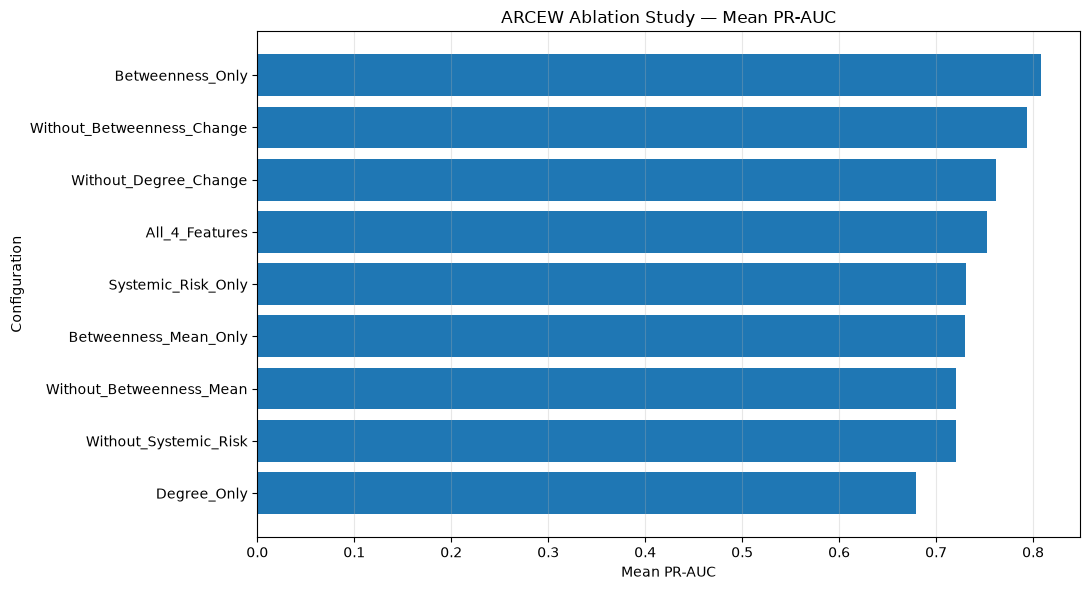

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\ablation_mean_pr_auc.png


In [44]:
# Cell 43: Visualize ablation study performance

import matplotlib.pyplot as plt

plot_data = ablation_summary_df.sort_values(
    "mean_pr_auc",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_data["configuration"],
    plot_data["mean_pr_auc"]
)

plt.xlabel("Mean PR-AUC")
plt.ylabel("Configuration")
plt.title("ARCEW Ablation Study — Mean PR-AUC")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

output_path = (
    PHASE16_DIR /
    "ablation_mean_pr_auc.png"
)

plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)

In [45]:
# Cell 44: Analyze feature removal effects

full_model = ablation_summary_df[
    ablation_summary_df["configuration"] == "All_4_Features"
].iloc[0]

full_pr_auc = full_model["mean_pr_auc"]
full_roc_auc = full_model["mean_roc_auc"]

removal_effects = []

for _, row in ablation_summary_df.iterrows():

    if row["configuration"] == "All_4_Features":
        continue

    removal_effects.append({
        "configuration": row["configuration"],
        "pr_auc_change_vs_full": (
            row["mean_pr_auc"] - full_pr_auc
        ),
        "roc_auc_change_vs_full": (
            row["mean_roc_auc"] - full_roc_auc
        ),
        "mean_pr_auc": row["mean_pr_auc"],
        "mean_roc_auc": row["mean_roc_auc"]
    })

removal_effects_df = pd.DataFrame(
    removal_effects
).sort_values(
    "pr_auc_change_vs_full",
    ascending=False
)

display(removal_effects_df)

output_path = (
    PHASE16_DIR /
    "feature_removal_effects.csv"
)

removal_effects_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,pr_auc_change_vs_full,roc_auc_change_vs_full,mean_pr_auc,mean_roc_auc
0,Betweenness_Only,0.055871,-0.013889,0.807955,0.774306
1,Without_Betweenness_Change,0.041667,0.013889,0.793750,0.802083
2,Without_Degree_Change,0.009821,-0.052083,0.761905,0.736111
3,Systemic_Risk_Only,-0.020833,-0.027778,0.731250,0.760417
4,Betweenness_Mean_Only,-0.022321,0.006944,0.729762,0.795139
5,Without_Betweenness_Mean,-0.031250,-0.052083,0.720833,0.736111
6,Without_Systemic_Risk,-0.031845,-0.083333,0.720238,0.704861
7,Degree_Only,-0.072917,-0.079861,0.679167,0.708333


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\feature_removal_effects.csv


In [46]:
# Cell 45: Standardized leakage-safe evaluation function

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

def evaluate_configuration(
    train_data,
    validation_data,
    features
):
    """
    Standardized evaluation:
    1. Fit scaler on training data only.
    2. Select direction for each feature using training data only.
    3. Average signed standardized features.
    4. Evaluate on validation data.
    """

    valid_features = [
        feature for feature in features
        if feature in train_data.columns
        and feature in validation_data.columns
    ]

    if len(valid_features) == 0:
        return None

    y_train = train_data["date_stress_event"].astype(int).values
    y_validation = (
        validation_data["date_stress_event"]
        .astype(int)
        .values
    )

    if len(np.unique(y_train)) < 2:
        return None

    if len(np.unique(y_validation)) < 2:
        return None

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train_data[valid_features]
    )

    X_validation = scaler.transform(
        validation_data[valid_features]
    )

    signed_train_features = []
    signed_validation_features = []

    feature_directions = {}

    for index, feature in enumerate(valid_features):

        train_feature_score = X_train[:, index]
        validation_feature_score = X_validation[:, index]

        normal_auc = roc_auc_score(
            y_train,
            train_feature_score
        )

        reversed_auc = roc_auc_score(
            y_train,
            -train_feature_score
        )

        if reversed_auc > normal_auc:
            direction = -1
        else:
            direction = 1

        feature_directions[feature] = (
            "reversed" if direction == -1 else "normal"
        )

        signed_train_features.append(
            direction * train_feature_score
        )

        signed_validation_features.append(
            direction * validation_feature_score
        )

    train_score = np.mean(
        signed_train_features,
        axis=0
    )

    validation_score = np.mean(
        signed_validation_features,
        axis=0
    )

    results = {
        "selected_features": ", ".join(valid_features),
        "feature_directions": str(feature_directions),
        "train_roc_auc": roc_auc_score(
            y_train,
            train_score
        ),
        "train_pr_auc": average_precision_score(
            y_train,
            train_score
        ),
        "validation_roc_auc": roc_auc_score(
            y_validation,
            validation_score
        ),
        "validation_pr_auc": average_precision_score(
            y_validation,
            validation_score
        )
    }

    return results

In [47]:
# Cell 46: Recompute all ablation configurations consistently

standardized_results = []

full_data = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

for window in event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(
        window["validation_start"]
    )
    validation_end = pd.to_datetime(
        window["validation_end"]
    )

    train_data = full_data[
        full_data["date"] <= train_end
    ].copy()

    validation_data = full_data[
        (
            full_data["date"] >= validation_start
        )
        &
        (
            full_data["date"] <= validation_end
        )
    ].copy()

    for configuration_name, features in (
        ablation_configurations.items()
    ):

        evaluation = evaluate_configuration(
            train_data=train_data,
            validation_data=validation_data,
            features=features
        )

        if evaluation is None:
            continue

        standardized_results.append({
            "configuration": configuration_name,
            "window": window["name"],
            "train_count": len(train_data),
            "validation_count": len(validation_data),
            "train_positive_count": int(
                train_data["date_stress_event"].sum()
            ),
            "validation_positive_count": int(
                validation_data["date_stress_event"].sum()
            ),
            **evaluation
        })

standardized_results_df = pd.DataFrame(
    standardized_results
)

display(standardized_results_df)

output_path = (
    PHASE16_DIR /
    "standardized_ablation_results.csv"
)

standardized_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,window,train_count,validation_count,train_positive_count,validation_positive_count,selected_features,feature_directions,train_roc_auc,train_pr_auc,validation_roc_auc,validation_pr_auc
0,All_4_Features,Window_1_2022_late,11,13,7,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.678571,0.729592,0.888889,0.875000
1,Without_Betweenness_Mean,Window_1_2022_late,11,13,7,4,"betweenness_change, systemic_risk_score_change...","{'betweenness_change': 'normal', 'systemic_ris...",0.642857,0.714286,0.777778,0.704167
2,Without_Betweenness_Change,Window_1_2022_late,11,13,7,4,"betweenness_rolling_mean_3, systemic_risk_scor...","{'betweenness_rolling_mean_3': 'reversed', 'sy...",0.642857,0.714286,0.916667,0.854167
3,Without_Systemic_Risk,Window_1_2022_late,11,13,7,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.750000,0.754592,0.861111,0.812500
4,Without_Degree_Change,Window_1_2022_late,11,13,7,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.750000,0.754592,0.888889,0.875000
5,Betweenness_Only,Window_1_2022_late,11,13,7,4,betweenness_change,{'betweenness_change': 'normal'},0.500000,0.647712,0.611111,0.665909
6,Systemic_Risk_Only,Window_1_2022_late,11,13,7,4,systemic_risk_score_change,{'systemic_risk_score_change': 'reversed'},0.535714,0.676283,0.833333,0.729167
7,Degree_Only,Window_1_2022_late,11,13,7,4,degree_change,{'degree_change': 'reversed'},0.571429,0.678231,0.791667,0.666667
8,Betweenness_Mean_Only,Window_1_2022_late,11,13,7,4,betweenness_rolling_mean_3,{'betweenness_rolling_mean_3': 'reversed'},0.678571,0.808390,0.777778,0.566667
9,All_4_Features,Window_2_2025,73,8,11,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.579179,0.188143,0.937500,0.950000


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\standardized_ablation_results.csv


In [48]:
# Cell 47: Standardized ablation summary

standardized_summary_df = (
    standardized_results_df
    .groupby("configuration")
    .agg(
        windows=("window", "count"),
        mean_train_roc_auc=("train_roc_auc", "mean"),
        mean_validation_roc_auc=(
            "validation_roc_auc",
            "mean"
        ),
        mean_validation_pr_auc=(
            "validation_pr_auc",
            "mean"
        ),
        min_validation_roc_auc=(
            "validation_roc_auc",
            "min"
        ),
        max_validation_roc_auc=(
            "validation_roc_auc",
            "max"
        ),
        min_validation_pr_auc=(
            "validation_pr_auc",
            "min"
        ),
        max_validation_pr_auc=(
            "validation_pr_auc",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_validation_pr_auc",
        ascending=False
    )
)

display(standardized_summary_df)

output_path = (
    PHASE16_DIR /
    "standardized_ablation_summary.csv"
)

standardized_summary_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,windows,mean_train_roc_auc,mean_validation_roc_auc,mean_validation_pr_auc,min_validation_roc_auc,max_validation_roc_auc,min_validation_pr_auc,max_validation_pr_auc
7,Without_Degree_Change,2,0.657991,0.944444,0.937500,0.888889,1.000000,0.875000,1.000000
0,All_4_Features,2,0.628875,0.913194,0.912500,0.888889,0.937500,0.875000,0.950000
8,Without_Systemic_Risk,2,0.656525,0.930556,0.906250,0.861111,1.000000,0.812500,1.000000
2,Betweenness_Only,2,0.523827,0.774306,0.807955,0.611111,0.937500,0.665909,0.950000
5,Without_Betweenness_Change,2,0.618349,0.802083,0.793750,0.687500,0.916667,0.733333,0.854167
6,Without_Betweenness_Mean,2,0.605153,0.763889,0.760417,0.750000,0.777778,0.704167,0.816667
4,Systemic_Risk_Only,2,0.557447,0.760417,0.731250,0.687500,0.833333,0.729167,0.733333
1,Betweenness_Mean_Only,2,0.618611,0.795139,0.729762,0.777778,0.812500,0.566667,0.892857
3,Degree_Only,2,0.570905,0.708333,0.679167,0.625000,0.791667,0.666667,0.691667


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\standardized_ablation_summary.csv


In [49]:
# Cell 48: Compare standardized All_4 result
# with the earlier stored results

print("Standardized results for All_4_Features:")

display(
    standardized_results_df[
        standardized_results_df["configuration"]
        == "All_4_Features"
    ][[
        "window",
        "train_roc_auc",
        "train_pr_auc",
        "validation_roc_auc",
        "validation_pr_auc",
        "feature_directions"
    ]]
)

print("\nStandardized summary for All_4_Features:")

display(
    standardized_summary_df[
        standardized_summary_df["configuration"]
        == "All_4_Features"
    ]
)

print("\nEarlier composite summary, if available:")

if "clean_composite_summary" in globals():
    display(clean_composite_summary)

else:
    earlier_path = (
        PHASE16_DIR /
        "clean_composite_summary.csv"
    )

    if earlier_path.exists():
        earlier_summary = pd.read_csv(
            earlier_path
        )
        display(earlier_summary)

    else:
        print(
            "Earlier composite summary was not found."
        )

Standardized results for All_4_Features:


,window,train_roc_auc,train_pr_auc,validation_roc_auc,validation_pr_auc,feature_directions
0,Window_1_2022_late,0.678571,0.729592,0.888889,0.875,"{'betweenness_rolling_mean_3': 'reversed', 'be..."
9,Window_2_2025,0.579179,0.188143,0.937500,0.950,"{'betweenness_rolling_mean_3': 'reversed', 'be..."



Standardized summary for All_4_Features:


,configuration,windows,mean_train_roc_auc,mean_validation_roc_auc,mean_validation_pr_auc,min_validation_roc_auc,max_validation_roc_auc,min_validation_pr_auc,max_validation_pr_auc
0,All_4_Features,2,0.628875,0.913194,0.9125,0.888889,0.9375,0.875,0.95



Earlier composite summary, if available:


,window,feature,direction,validation_roc_auc,validation_pr_auc
0,Window_1_2022_late,COMPOSITE_SIGNAL,training_aligned,0.888889,0.875
1,Window_2_2025,COMPOSITE_SIGNAL,training_aligned,0.937500,0.950


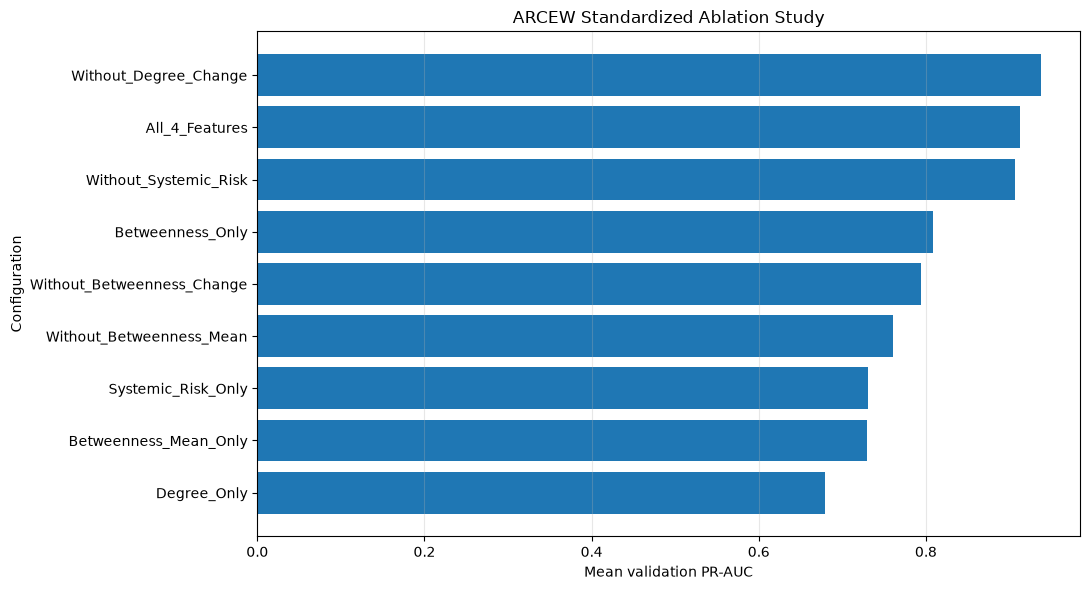

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\standardized_ablation_mean_pr_auc.png


In [50]:
# Cell 49: Visualize standardized mean PR-AUC

import matplotlib.pyplot as plt

plot_data = (
    standardized_summary_df
    .sort_values(
        "mean_validation_pr_auc",
        ascending=True
    )
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_data["configuration"],
    plot_data["mean_validation_pr_auc"]
)

plt.xlabel("Mean validation PR-AUC")
plt.ylabel("Configuration")

plt.title(
    "ARCEW Standardized Ablation Study"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

output_path = (
    PHASE16_DIR /
    "standardized_ablation_mean_pr_auc.png"
)

plt.savefig(
    output_path,
    dpi=300
)

plt.show()

print("Saved:", output_path)

In [51]:
# Cell 50: Extended event-aware evaluation windows

extended_event_windows = [
    {
        "name": "Window_1_2022_mid",
        "train_end": "2022-03-31",
        "validation_start": "2022-04-01",
        "validation_end": "2022-06-30"
    },
    {
        "name": "Window_2_2022_late",
        "train_end": "2022-06-30",
        "validation_start": "2022-07-01",
        "validation_end": "2022-12-31"
    },
    {
        "name": "Window_3_2025",
        "train_end": "2024-12-31",
        "validation_start": "2025-01-01",
        "validation_end": "2025-04-30"
    }
]

for window in extended_event_windows:
    print(
        window["name"],
        "| Train end:", window["train_end"],
        "| Validation:",
        window["validation_start"],
        "to",
        window["validation_end"]
    )

Window_1_2022_mid | Train end: 2022-03-31 | Validation: 2022-04-01 to 2022-06-30
Window_2_2022_late | Train end: 2022-06-30 | Validation: 2022-07-01 to 2022-12-31
Window_3_2025 | Train end: 2024-12-31 | Validation: 2025-01-01 to 2025-04-30


In [52]:
# Cell 51: Evaluate all configurations on extended windows

extended_results = []

full_data = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

for window in extended_event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(
        window["validation_start"]
    )
    validation_end = pd.to_datetime(
        window["validation_end"]
    )

    train_data = full_data[
        full_data["date"] <= train_end
    ].copy()

    validation_data = full_data[
        (
            full_data["date"] >= validation_start
        )
        &
        (
            full_data["date"] <= validation_end
        )
    ].copy()

    print(
        f"\n{window['name']}:",
        f"Train={len(train_data)}",
        f"Validation={len(validation_data)}",
        f"Validation stress={validation_data['date_stress_event'].sum()}"
    )

    for configuration_name, features in (
        ablation_configurations.items()
    ):

        evaluation = evaluate_configuration(
            train_data=train_data,
            validation_data=validation_data,
            features=features
        )

        if evaluation is None:
            continue

        extended_results.append({
            "configuration": configuration_name,
            "window": window["name"],
            "train_count": len(train_data),
            "validation_count": len(validation_data),
            "train_positive_count": int(
                train_data["date_stress_event"].sum()
            ),
            "validation_positive_count": int(
                validation_data["date_stress_event"].sum()
            ),
            **evaluation
        })

extended_results_df = pd.DataFrame(
    extended_results
)

display(extended_results_df)

output_path = (
    PHASE16_DIR /
    "extended_walkforward_ablation_results.csv"
)

extended_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)


Window_1_2022_mid: Train=5 Validation=6 Validation stress=5

Window_2_2022_late: Train=11 Validation=13 Validation stress=4

Window_3_2025: Train=73 Validation=8 Validation stress=4


,configuration,window,train_count,validation_count,train_positive_count,validation_positive_count,selected_features,feature_directions,train_roc_auc,train_pr_auc,validation_roc_auc,validation_pr_auc
0,All_4_Features,Window_1_2022_mid,5,6,2,5,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",1.000000,1.000000,0.000000,0.710000
1,Without_Betweenness_Mean,Window_1_2022_mid,5,6,2,5,"betweenness_change, systemic_risk_score_change...","{'betweenness_change': 'normal', 'systemic_ris...",1.000000,1.000000,0.000000,0.710000
2,Without_Betweenness_Change,Window_1_2022_mid,5,6,2,5,"betweenness_rolling_mean_3, systemic_risk_scor...","{'betweenness_rolling_mean_3': 'reversed', 'sy...",1.000000,1.000000,0.000000,0.710000
3,Without_Systemic_Risk,Window_1_2022_mid,5,6,2,5,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",1.000000,1.000000,0.000000,0.710000
4,Without_Degree_Change,Window_1_2022_mid,5,6,2,5,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",1.000000,1.000000,0.000000,0.710000
5,Betweenness_Only,Window_1_2022_mid,5,6,2,5,betweenness_change,{'betweenness_change': 'normal'},0.833333,0.833333,0.000000,0.710000
6,Systemic_Risk_Only,Window_1_2022_mid,5,6,2,5,systemic_risk_score_change,{'systemic_risk_score_change': 'reversed'},0.666667,0.750000,0.000000,0.710000
7,Degree_Only,Window_1_2022_mid,5,6,2,5,degree_change,{'degree_change': 'reversed'},1.000000,1.000000,0.000000,0.710000
8,Betweenness_Mean_Only,Window_1_2022_mid,5,6,2,5,betweenness_rolling_mean_3,{'betweenness_rolling_mean_3': 'reversed'},1.000000,1.000000,0.000000,0.710000
9,All_4_Features,Window_2_2022_late,11,13,7,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.678571,0.729592,0.888889,0.875000


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\extended_walkforward_ablation_results.csv


In [53]:
# Cell 52: Extended walk-forward summary

extended_summary_df = (
    extended_results_df
    .groupby("configuration")
    .agg(
        windows=("window", "count"),
        mean_roc_auc=(
            "validation_roc_auc",
            "mean"
        ),
        mean_pr_auc=(
            "validation_pr_auc",
            "mean"
        ),
        min_roc_auc=(
            "validation_roc_auc",
            "min"
        ),
        max_roc_auc=(
            "validation_roc_auc",
            "max"
        ),
        min_pr_auc=(
            "validation_pr_auc",
            "min"
        ),
        max_pr_auc=(
            "validation_pr_auc",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_pr_auc",
        ascending=False
    )
)

display(extended_summary_df)

output_path = (
    PHASE16_DIR /
    "extended_walkforward_ablation_summary.csv"
)

extended_summary_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,windows,mean_roc_auc,mean_pr_auc,min_roc_auc,max_roc_auc,min_pr_auc,max_pr_auc
7,Without_Degree_Change,3,0.629630,0.861667,0.0,1.000000,0.710000,1.000000
0,All_4_Features,3,0.608796,0.845000,0.0,0.937500,0.710000,0.950000
8,Without_Systemic_Risk,3,0.620370,0.840833,0.0,1.000000,0.710000,1.000000
2,Betweenness_Only,3,0.516204,0.775303,0.0,0.937500,0.665909,0.950000
5,Without_Betweenness_Change,3,0.534722,0.765833,0.0,0.916667,0.710000,0.854167
6,Without_Betweenness_Mean,3,0.509259,0.743611,0.0,0.777778,0.704167,0.816667
4,Systemic_Risk_Only,3,0.506944,0.724167,0.0,0.833333,0.710000,0.733333
1,Betweenness_Mean_Only,3,0.530093,0.723175,0.0,0.812500,0.566667,0.892857
3,Degree_Only,3,0.472222,0.689444,0.0,0.791667,0.666667,0.710000


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\extended_walkforward_ablation_summary.csv


In [54]:
# Cell 53: Per-window performance comparison

display(
    extended_results_df[
        [
            "configuration",
            "window",
            "validation_count",
            "validation_positive_count",
            "validation_roc_auc",
            "validation_pr_auc"
        ]
    ]
    .sort_values(
        ["window", "validation_pr_auc"],
        ascending=[True, False]
    )
)

,configuration,window,validation_count,validation_positive_count,validation_roc_auc,validation_pr_auc
0,All_4_Features,Window_1_2022_mid,6,5,0.000000,0.710000
1,Without_Betweenness_Mean,Window_1_2022_mid,6,5,0.000000,0.710000
2,Without_Betweenness_Change,Window_1_2022_mid,6,5,0.000000,0.710000
3,Without_Systemic_Risk,Window_1_2022_mid,6,5,0.000000,0.710000
4,Without_Degree_Change,Window_1_2022_mid,6,5,0.000000,0.710000
5,Betweenness_Only,Window_1_2022_mid,6,5,0.000000,0.710000
6,Systemic_Risk_Only,Window_1_2022_mid,6,5,0.000000,0.710000
7,Degree_Only,Window_1_2022_mid,6,5,0.000000,0.710000
8,Betweenness_Mean_Only,Window_1_2022_mid,6,5,0.000000,0.710000
9,All_4_Features,Window_2_2022_late,13,4,0.888889,0.875000


In [55]:
# Cell 54: Measure performance stability

stability_df = (
    extended_results_df
    .groupby("configuration")
    .agg(
        windows=("window", "count"),
        mean_pr_auc=("validation_pr_auc", "mean"),
        std_pr_auc=("validation_pr_auc", "std"),
        mean_roc_auc=("validation_roc_auc", "mean"),
        std_roc_auc=("validation_roc_auc", "std")
    )
    .reset_index()
)

stability_df["pr_auc_coefficient_of_variation"] = (
    stability_df["std_pr_auc"]
    / stability_df["mean_pr_auc"]
)

stability_df = stability_df.sort_values(
    "std_pr_auc",
    ascending=True
)

display(stability_df)

output_path = (
    PHASE16_DIR /
    "extended_model_stability_analysis.csv"
)

stability_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,windows,mean_pr_auc,std_pr_auc,mean_roc_auc,std_roc_auc,pr_auc_coefficient_of_variation
4,Systemic_Risk_Only,3,0.724167,0.012444,0.506944,0.445041,0.017184
3,Degree_Only,3,0.689444,0.021752,0.472222,0.417361,0.031550
6,Without_Betweenness_Mean,3,0.743611,0.063335,0.509259,0.441250,0.085172
5,Without_Betweenness_Change,3,0.765833,0.077383,0.534722,0.477048,0.101045
0,All_4_Features,3,0.845000,0.122780,0.608796,0.527793,0.145302
7,Without_Degree_Change,3,0.861667,0.145459,0.629630,0.548098,0.168811
8,Without_Systemic_Risk,3,0.840833,0.147061,0.620370,0.541726,0.174900
2,Betweenness_Only,3,0.775303,0.152890,0.516204,0.475901,0.197200
1,Betweenness_Mean_Only,3,0.723175,0.163494,0.530093,0.459402,0.226078


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\extended_model_stability_analysis.csv


In [56]:
# Cell 55: Check evaluation-window reliability

window_quality_df = (
    extended_results_df
    .groupby("window")
    .agg(
        validation_count=("validation_count", "first"),
        positive_count=(
            "validation_positive_count",
            "first"
        )
    )
    .reset_index()
)

window_quality_df["negative_count"] = (
    window_quality_df["validation_count"]
    - window_quality_df["positive_count"]
)

window_quality_df["reliability_flag"] = np.where(
    (
        (window_quality_df["validation_count"] < 10)
        |
        (window_quality_df["positive_count"] < 2)
        |
        (window_quality_df["negative_count"] < 2)
    ),
    "Low sample reliability",
    "Usable for exploratory analysis"
)

display(window_quality_df)

output_path = (
    PHASE16_DIR /
    "evaluation_window_quality.csv"
)

window_quality_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,validation_count,positive_count,negative_count,reliability_flag
0,Window_1_2022_mid,6,5,1,Low sample reliability
1,Window_2_2022_late,13,4,9,Usable for exploratory analysis
2,Window_3_2025,8,4,4,Low sample reliability


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\evaluation_window_quality.csv


In [57]:
# Cell 56: Sensitivity analysis excluding low-sample windows

reliable_windows = window_quality_df[
    window_quality_df["reliability_flag"]
    == "Usable for exploratory analysis"
]["window"].tolist()

reliable_results_df = extended_results_df[
    extended_results_df["window"].isin(
        reliable_windows
    )
].copy()

reliable_summary_df = (
    reliable_results_df
    .groupby("configuration")
    .agg(
        windows=("window", "count"),
        mean_roc_auc=(
            "validation_roc_auc",
            "mean"
        ),
        mean_pr_auc=(
            "validation_pr_auc",
            "mean"
        ),
        std_pr_auc=(
            "validation_pr_auc",
            "std"
        ),
        min_roc_auc=(
            "validation_roc_auc",
            "min"
        ),
        max_roc_auc=(
            "validation_roc_auc",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_pr_auc",
        ascending=False
    )
)

display(reliable_summary_df)

output_path = (
    PHASE16_DIR /
    "reliable_window_sensitivity_summary.csv"
)

reliable_summary_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,windows,mean_roc_auc,mean_pr_auc,std_pr_auc,min_roc_auc,max_roc_auc
0,All_4_Features,1,0.888889,0.875000,NaN,0.888889,0.888889
7,Without_Degree_Change,1,0.888889,0.875000,NaN,0.888889,0.888889
5,Without_Betweenness_Change,1,0.916667,0.854167,NaN,0.916667,0.916667
8,Without_Systemic_Risk,1,0.861111,0.812500,NaN,0.861111,0.861111
4,Systemic_Risk_Only,1,0.833333,0.729167,NaN,0.833333,0.833333
6,Without_Betweenness_Mean,1,0.777778,0.704167,NaN,0.777778,0.777778
3,Degree_Only,1,0.791667,0.666667,NaN,0.791667,0.791667
2,Betweenness_Only,1,0.611111,0.665909,NaN,0.611111,0.611111
1,Betweenness_Mean_Only,1,0.777778,0.566667,NaN,0.777778,0.777778


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\reliable_window_sensitivity_summary.csv


In [58]:
# Cell 57: Compare rankings before and after filtering

comparison_df = extended_summary_df[
    [
        "configuration",
        "mean_pr_auc",
        "mean_roc_auc"
    ]
].rename(
    columns={
        "mean_pr_auc": "all_windows_mean_pr_auc",
        "mean_roc_auc": "all_windows_mean_roc_auc"
    }
)

comparison_df = comparison_df.merge(
    reliable_summary_df[
        [
            "configuration",
            "mean_pr_auc",
            "mean_roc_auc"
        ]
    ].rename(
        columns={
            "mean_pr_auc": "reliable_windows_mean_pr_auc",
            "mean_roc_auc": "reliable_windows_mean_roc_auc"
        }
    ),
    on="configuration",
    how="left"
)

display(
    comparison_df.sort_values(
        "reliable_windows_mean_pr_auc",
        ascending=False
    )
)

,configuration,all_windows_mean_pr_auc,all_windows_mean_roc_auc,reliable_windows_mean_pr_auc,reliable_windows_mean_roc_auc
0,Without_Degree_Change,0.861667,0.629630,0.875000,0.888889
1,All_4_Features,0.845000,0.608796,0.875000,0.888889
4,Without_Betweenness_Change,0.765833,0.534722,0.854167,0.916667
2,Without_Systemic_Risk,0.840833,0.620370,0.812500,0.861111
6,Systemic_Risk_Only,0.724167,0.506944,0.729167,0.833333
5,Without_Betweenness_Mean,0.743611,0.509259,0.704167,0.777778
8,Degree_Only,0.689444,0.472222,0.666667,0.791667
3,Betweenness_Only,0.775303,0.516204,0.665909,0.611111
7,Betweenness_Mean_Only,0.723175,0.530093,0.566667,0.777778


In [59]:
# Cell 58: Broader evaluation windows

broader_event_windows = [
    {
        "name": "Window_1_2022_full",
        "train_end": "2021-12-31",
        "validation_start": "2022-01-01",
        "validation_end": "2022-12-31"
    },
    {
        "name": "Window_2_2023",
        "train_end": "2022-12-31",
        "validation_start": "2023-01-01",
        "validation_end": "2023-12-31"
    },
    {
        "name": "Window_3_2024",
        "train_end": "2023-12-31",
        "validation_start": "2024-01-01",
        "validation_end": "2024-12-31"
    },
    {
        "name": "Window_4_2025",
        "train_end": "2024-12-31",
        "validation_start": "2025-01-01",
        "validation_end": "2025-12-31"
    }
]

for window in broader_event_windows:
    print(
        window["name"],
        "| Train end:", window["train_end"],
        "| Validation:",
        window["validation_start"],
        "to",
        window["validation_end"]
    )

Window_1_2022_full | Train end: 2021-12-31 | Validation: 2022-01-01 to 2022-12-31
Window_2_2023 | Train end: 2022-12-31 | Validation: 2023-01-01 to 2023-12-31
Window_3_2024 | Train end: 2023-12-31 | Validation: 2024-01-01 to 2024-12-31
Window_4_2025 | Train end: 2024-12-31 | Validation: 2025-01-01 to 2025-12-31


In [60]:
# Cell 59: Check sample sizes before evaluation

full_data = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

window_check = []

for window in broader_event_windows:

    validation_start = pd.to_datetime(
        window["validation_start"]
    )

    validation_end = pd.to_datetime(
        window["validation_end"]
    )

    validation_data = full_data[
        (
            full_data["date"] >= validation_start
        )
        &
        (
            full_data["date"] <= validation_end
        )
    ]

    total_count = len(validation_data)
    positive_count = int(
        validation_data["date_stress_event"].sum()
    )
    negative_count = total_count - positive_count

    window_check.append({
        "window": window["name"],
        "validation_count": total_count,
        "positive_count": positive_count,
        "negative_count": negative_count,
        "has_both_classes": (
            positive_count > 0
            and negative_count > 0
        )
    })

window_check_df = pd.DataFrame(window_check)

display(window_check_df)

,window,validation_count,positive_count,negative_count,has_both_classes
0,Window_1_2022_full,23,10,13,True
1,Window_2_2023,25,0,25,False
2,Window_3_2024,24,0,24,False
3,Window_4_2025,19,4,15,True


In [61]:
# Cell 60: Evaluate configurations on usable broader windows

broader_results = []

full_data = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

for window in broader_event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(
        window["validation_start"]
    )
    validation_end = pd.to_datetime(
        window["validation_end"]
    )

    train_data = full_data[
        full_data["date"] <= train_end
    ].copy()

    validation_data = full_data[
        (
            full_data["date"] >= validation_start
        )
        &
        (
            full_data["date"] <= validation_end
        )
    ].copy()

    positive_count = int(
        validation_data["date_stress_event"].sum()
    )

    negative_count = (
        len(validation_data) - positive_count
    )

    if positive_count == 0 or negative_count == 0:
        print(
            f"Skipping {window['name']}: "
            f"positive={positive_count}, "
            f"negative={negative_count}"
        )
        continue

    print(
        f"\nEvaluating {window['name']}: "
        f"train={len(train_data)}, "
        f"validation={len(validation_data)}, "
        f"stress={positive_count}"
    )

    for configuration_name, features in (
        ablation_configurations.items()
    ):

        evaluation = evaluate_configuration(
            train_data=train_data,
            validation_data=validation_data,
            features=features
        )

        if evaluation is None:
            continue

        broader_results.append({
            "configuration": configuration_name,
            "window": window["name"],
            "train_count": len(train_data),
            "validation_count": len(validation_data),
            "train_positive_count": int(
                train_data["date_stress_event"].sum()
            ),
            "validation_positive_count": positive_count,
            **evaluation
        })

broader_results_df = pd.DataFrame(
    broader_results
)

display(broader_results_df)

output_path = (
    PHASE16_DIR /
    "broader_walkforward_results.csv"
)

broader_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)


Evaluating Window_1_2022_full: train=1, validation=23, stress=10
Skipping Window_2_2023: positive=0, negative=25
Skipping Window_3_2024: positive=0, negative=24

Evaluating Window_4_2025: train=73, validation=19, stress=4


,configuration,window,train_count,validation_count,train_positive_count,validation_positive_count,selected_features,feature_directions,train_roc_auc,train_pr_auc,validation_roc_auc,validation_pr_auc
0,All_4_Features,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.579179,0.188143,0.983333,0.950000
1,Without_Betweenness_Mean,Window_4_2025,73,19,11,4,"betweenness_change, systemic_risk_score_change...","{'betweenness_change': 'normal', 'systemic_ris...",0.567449,0.197333,0.933333,0.816667
2,Without_Betweenness_Change,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, systemic_risk_scor...","{'betweenness_rolling_mean_3': 'reversed', 'sy...",0.593842,0.185410,0.900000,0.709524
3,Without_Systemic_Risk,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.563050,0.177225,0.950000,0.854167
4,Without_Degree_Change,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.565982,0.194107,0.916667,0.861111
5,Betweenness_Only,Window_4_2025,73,19,11,4,betweenness_change,{'betweenness_change': 'normal'},0.547654,0.200179,0.966667,0.916667
6,Systemic_Risk_Only,Window_4_2025,73,19,11,4,systemic_risk_score_change,{'systemic_risk_score_change': 'normal'},0.579179,0.258278,0.916667,0.733333
7,Degree_Only,Window_4_2025,73,19,11,4,degree_change,{'degree_change': 'normal'},0.570381,0.185676,0.866667,0.650000
8,Betweenness_Mean_Only,Window_4_2025,73,19,11,4,betweenness_rolling_mean_3,{'betweenness_rolling_mean_3': 'reversed'},0.558651,0.181310,0.433333,0.220629


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\broader_walkforward_results.csv


In [62]:
# Cell 60: Evaluate configurations on usable broader windows

broader_results = []

full_data = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

for window in broader_event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(
        window["validation_start"]
    )
    validation_end = pd.to_datetime(
        window["validation_end"]
    )

    train_data = full_data[
        full_data["date"] <= train_end
    ].copy()

    validation_data = full_data[
        (
            full_data["date"] >= validation_start
        )
        &
        (
            full_data["date"] <= validation_end
        )
    ].copy()

    positive_count = int(
        validation_data["date_stress_event"].sum()
    )

    negative_count = (
        len(validation_data) - positive_count
    )

    if positive_count == 0 or negative_count == 0:
        print(
            f"Skipping {window['name']}: "
            f"positive={positive_count}, "
            f"negative={negative_count}"
        )
        continue

    print(
        f"\nEvaluating {window['name']}: "
        f"train={len(train_data)}, "
        f"validation={len(validation_data)}, "
        f"stress={positive_count}"
    )

    for configuration_name, features in (
        ablation_configurations.items()
    ):

        evaluation = evaluate_configuration(
            train_data=train_data,
            validation_data=validation_data,
            features=features
        )

        if evaluation is None:
            continue

        broader_results.append({
            "configuration": configuration_name,
            "window": window["name"],
            "train_count": len(train_data),
            "validation_count": len(validation_data),
            "train_positive_count": int(
                train_data["date_stress_event"].sum()
            ),
            "validation_positive_count": positive_count,
            **evaluation
        })

broader_results_df = pd.DataFrame(
    broader_results
)

display(broader_results_df)

output_path = (
    PHASE16_DIR /
    "broader_walkforward_results.csv"
)

broader_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)


Evaluating Window_1_2022_full: train=1, validation=23, stress=10
Skipping Window_2_2023: positive=0, negative=25
Skipping Window_3_2024: positive=0, negative=24

Evaluating Window_4_2025: train=73, validation=19, stress=4


,configuration,window,train_count,validation_count,train_positive_count,validation_positive_count,selected_features,feature_directions,train_roc_auc,train_pr_auc,validation_roc_auc,validation_pr_auc
0,All_4_Features,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.579179,0.188143,0.983333,0.950000
1,Without_Betweenness_Mean,Window_4_2025,73,19,11,4,"betweenness_change, systemic_risk_score_change...","{'betweenness_change': 'normal', 'systemic_ris...",0.567449,0.197333,0.933333,0.816667
2,Without_Betweenness_Change,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, systemic_risk_scor...","{'betweenness_rolling_mean_3': 'reversed', 'sy...",0.593842,0.185410,0.900000,0.709524
3,Without_Systemic_Risk,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.563050,0.177225,0.950000,0.854167
4,Without_Degree_Change,Window_4_2025,73,19,11,4,"betweenness_rolling_mean_3, betweenness_change...","{'betweenness_rolling_mean_3': 'reversed', 'be...",0.565982,0.194107,0.916667,0.861111
5,Betweenness_Only,Window_4_2025,73,19,11,4,betweenness_change,{'betweenness_change': 'normal'},0.547654,0.200179,0.966667,0.916667
6,Systemic_Risk_Only,Window_4_2025,73,19,11,4,systemic_risk_score_change,{'systemic_risk_score_change': 'normal'},0.579179,0.258278,0.916667,0.733333
7,Degree_Only,Window_4_2025,73,19,11,4,degree_change,{'degree_change': 'normal'},0.570381,0.185676,0.866667,0.650000
8,Betweenness_Mean_Only,Window_4_2025,73,19,11,4,betweenness_rolling_mean_3,{'betweenness_rolling_mean_3': 'reversed'},0.558651,0.181310,0.433333,0.220629


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\broader_walkforward_results.csv


In [63]:
# Cell 62: Audit training and validation sizes

full_data = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

window_audit = []

for window in broader_event_windows:

    train_end = pd.to_datetime(window["train_end"])
    validation_start = pd.to_datetime(
        window["validation_start"]
    )
    validation_end = pd.to_datetime(
        window["validation_end"]
    )

    train_data = full_data[
        full_data["date"] <= train_end
    ]

    validation_data = full_data[
        (
            full_data["date"] >= validation_start
        )
        &
        (
            full_data["date"] <= validation_end
        )
    ]

    train_positive = int(
        train_data["date_stress_event"].sum()
    )

    validation_positive = int(
        validation_data["date_stress_event"].sum()
    )

    window_audit.append({
        "window": window["name"],
        "train_count": len(train_data),
        "train_positive_count": train_positive,
        "validation_count": len(validation_data),
        "validation_positive_count": validation_positive,
        "validation_negative_count": (
            len(validation_data) - validation_positive
        ),
        "train_has_both_classes": (
            train_positive > 0
            and train_positive < len(train_data)
        ),
        "validation_has_both_classes": (
            validation_positive > 0
            and validation_positive < len(validation_data)
        ),
        "minimum_train_size_met": len(train_data) >= 10,
        "minimum_validation_size_met": (
            len(validation_data) >= 10
        )
    })

window_audit_df = pd.DataFrame(window_audit)

display(window_audit_df)

output_path = (
    PHASE16_DIR /
    "broader_window_audit.csv"
)

window_audit_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,train_count,train_positive_count,validation_count,validation_positive_count,validation_negative_count,train_has_both_classes,validation_has_both_classes,minimum_train_size_met,minimum_validation_size_met
0,Window_1_2022_full,1,1,23,10,13,False,True,False,True
1,Window_2_2023,24,11,25,0,25,True,False,True,True
2,Window_3_2024,49,11,24,0,24,True,False,True,True
3,Window_4_2025,73,11,19,4,15,True,True,True,True


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\broader_window_audit.csv


In [64]:
# Cell 63: Compare the two usable event periods

usable_window_names = [
    "Window_2_2022_late",
    "Window_4_2025"
]

usable_results_df = pd.concat(
    [
        extended_results_df[
            extended_results_df["window"]
            == "Window_2_2022_late"
        ],
        broader_results_df[
            broader_results_df["window"]
            == "Window_4_2025"
        ]
    ],
    ignore_index=True
)

display(
    usable_results_df[
        [
            "configuration",
            "window",
            "validation_count",
            "validation_positive_count",
            "validation_roc_auc",
            "validation_pr_auc"
        ]
    ]
    .sort_values(
        ["window", "validation_pr_auc"],
        ascending=[True, False]
    )
)

,configuration,window,validation_count,validation_positive_count,validation_roc_auc,validation_pr_auc
0,All_4_Features,Window_2_2022_late,13,4,0.888889,0.875000
4,Without_Degree_Change,Window_2_2022_late,13,4,0.888889,0.875000
2,Without_Betweenness_Change,Window_2_2022_late,13,4,0.916667,0.854167
3,Without_Systemic_Risk,Window_2_2022_late,13,4,0.861111,0.812500
6,Systemic_Risk_Only,Window_2_2022_late,13,4,0.833333,0.729167
1,Without_Betweenness_Mean,Window_2_2022_late,13,4,0.777778,0.704167
7,Degree_Only,Window_2_2022_late,13,4,0.791667,0.666667
5,Betweenness_Only,Window_2_2022_late,13,4,0.611111,0.665909
8,Betweenness_Mean_Only,Window_2_2022_late,13,4,0.777778,0.566667
9,All_4_Features,Window_4_2025,19,4,0.983333,0.950000


In [65]:
# Cell 64: Combined usable-window summary

final_comparison_df = (
    usable_results_df
    .groupby("configuration")
    .agg(
        windows=("window", "count"),
        mean_roc_auc=(
            "validation_roc_auc",
            "mean"
        ),
        mean_pr_auc=(
            "validation_pr_auc",
            "mean"
        ),
        std_pr_auc=(
            "validation_pr_auc",
            "std"
        ),
        min_roc_auc=(
            "validation_roc_auc",
            "min"
        ),
        max_roc_auc=(
            "validation_roc_auc",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_pr_auc",
        ascending=False
    )
)

display(final_comparison_df)

output_path = (
    PHASE16_DIR /
    "final_usable_window_comparison.csv"
)

final_comparison_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,windows,mean_roc_auc,mean_pr_auc,std_pr_auc,min_roc_auc,max_roc_auc
0,All_4_Features,2,0.936111,0.912500,0.053033,0.888889,0.983333
7,Without_Degree_Change,2,0.902778,0.868056,0.009821,0.888889,0.916667
8,Without_Systemic_Risk,2,0.905556,0.833333,0.029463,0.861111,0.950000
2,Betweenness_Only,2,0.788889,0.791288,0.177312,0.611111,0.966667
5,Without_Betweenness_Change,2,0.908333,0.781845,0.102278,0.900000,0.916667
6,Without_Betweenness_Mean,2,0.855556,0.760417,0.079550,0.777778,0.933333
4,Systemic_Risk_Only,2,0.875000,0.731250,0.002946,0.833333,0.916667
3,Degree_Only,2,0.829167,0.658333,0.011785,0.791667,0.866667
1,Betweenness_Mean_Only,2,0.605556,0.393648,0.244686,0.433333,0.777778


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\final_usable_window_comparison.csv


In [66]:
# Cell 65: Compare PR-AUC against prevalence baseline

baseline_records = []

for _, row in usable_results_df.iterrows():

    validation_count = row["validation_count"]
    positive_count = row["validation_positive_count"]

    prevalence_baseline = (
        positive_count / validation_count
    )

    pr_auc = row["validation_pr_auc"]

    baseline_records.append({
        "configuration": row["configuration"],
        "window": row["window"],
        "validation_count": validation_count,
        "positive_count": positive_count,
        "prevalence_baseline": prevalence_baseline,
        "validation_pr_auc": pr_auc,
        "pr_auc_lift": (
            pr_auc / prevalence_baseline
            if prevalence_baseline > 0
            else np.nan
        )
    })

pr_lift_df = pd.DataFrame(baseline_records)

display(
    pr_lift_df.sort_values(
        ["window", "pr_auc_lift"],
        ascending=[True, False]
    )
)

output_path = (
    PHASE16_DIR /
    "pr_auc_baseline_lift_analysis.csv"
)

pr_lift_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,window,validation_count,positive_count,prevalence_baseline,validation_pr_auc,pr_auc_lift
0,All_4_Features,Window_2_2022_late,13,4,0.307692,0.875000,2.843750
4,Without_Degree_Change,Window_2_2022_late,13,4,0.307692,0.875000,2.843750
2,Without_Betweenness_Change,Window_2_2022_late,13,4,0.307692,0.854167,2.776042
3,Without_Systemic_Risk,Window_2_2022_late,13,4,0.307692,0.812500,2.640625
6,Systemic_Risk_Only,Window_2_2022_late,13,4,0.307692,0.729167,2.369792
1,Without_Betweenness_Mean,Window_2_2022_late,13,4,0.307692,0.704167,2.288542
7,Degree_Only,Window_2_2022_late,13,4,0.307692,0.666667,2.166667
5,Betweenness_Only,Window_2_2022_late,13,4,0.307692,0.665909,2.164205
8,Betweenness_Mean_Only,Window_2_2022_late,13,4,0.307692,0.566667,1.841667
9,All_4_Features,Window_4_2025,19,4,0.210526,0.950000,4.512500


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\pr_auc_baseline_lift_analysis.csv


In [67]:
# Cell 66: Aggregate PR-AUC lift

pr_lift_summary_df = (
    pr_lift_df
    .groupby("configuration")
    .agg(
        windows=("window", "count"),
        mean_pr_auc=("validation_pr_auc", "mean"),
        mean_baseline=("prevalence_baseline", "mean"),
        mean_pr_auc_lift=("pr_auc_lift", "mean"),
        min_pr_auc_lift=("pr_auc_lift", "min"),
        max_pr_auc_lift=("pr_auc_lift", "max")
    )
    .reset_index()
    .sort_values(
        "mean_pr_auc_lift",
        ascending=False
    )
)

display(pr_lift_summary_df)

output_path = (
    PHASE16_DIR /
    "pr_auc_lift_summary.csv"
)

pr_lift_summary_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,configuration,windows,mean_pr_auc,mean_baseline,mean_pr_auc_lift,min_pr_auc_lift,max_pr_auc_lift
0,All_4_Features,2,0.912500,0.259109,3.678125,2.843750,4.512500
7,Without_Degree_Change,2,0.868056,0.259109,3.467014,2.843750,4.090278
8,Without_Systemic_Risk,2,0.833333,0.259109,3.348958,2.640625,4.057292
2,Betweenness_Only,2,0.791288,0.259109,3.259186,2.164205,4.354167
6,Without_Betweenness_Mean,2,0.760417,0.259109,3.083854,2.288542,3.879167
5,Without_Betweenness_Change,2,0.781845,0.259109,3.073140,2.776042,3.370238
4,Systemic_Risk_Only,2,0.731250,0.259109,2.926563,2.369792,3.483333
3,Degree_Only,2,0.658333,0.259109,2.627083,2.166667,3.087500
1,Betweenness_Mean_Only,2,0.393648,0.259109,1.444827,1.047988,1.841667


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\pr_auc_lift_summary.csv


In [69]:
# Cell 67: Bootstrap confidence interval function

from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import pandas as pd


def bootstrap_auc_ci(
    y_true,
    scores,
    metric="roc_auc",
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42
):

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    rng = np.random.default_rng(random_state)

    bootstrap_scores = []

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            len(y_true),
            size=len(y_true)
        )

        y_sample = y_true[indices]
        score_sample = scores[indices]

        if len(np.unique(y_sample)) < 2:
            continue

        if metric == "roc_auc":

            value = roc_auc_score(
                y_sample,
                score_sample
            )

        elif metric == "pr_auc":

            value = average_precision_score(
                y_sample,
                score_sample
            )

        else:

            raise ValueError(
                "Metric must be 'roc_auc' or 'pr_auc'"
            )

        bootstrap_scores.append(value)

    if len(bootstrap_scores) < 100:

        return {
            "estimate": np.nan,
            "lower_ci": np.nan,
            "upper_ci": np.nan,
            "valid_bootstrap_samples": len(
                bootstrap_scores
            )
        }

    alpha = 1 - confidence

    lower = np.percentile(
        bootstrap_scores,
        100 * (alpha / 2)
    )

    upper = np.percentile(
        bootstrap_scores,
        100 * (1 - alpha / 2)
    )

    return {
        "estimate": np.mean(bootstrap_scores),
        "lower_ci": lower,
        "upper_ci": upper,
        "valid_bootstrap_samples": len(
            bootstrap_scores
        )
    }


print("Bootstrap function created successfully.")

Bootstrap function created successfully.


In [70]:
# Cell 68: Prepare scores for bootstrap evaluation

bootstrap_records = []

full_data = (
    model_df
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

for window in event_windows:

    train_end = pd.to_datetime(window["train_end"])

    validation_start = pd.to_datetime(
        window["validation_start"]
    )

    validation_end = pd.to_datetime(
        window["validation_end"]
    )

    train_data = full_data[
        full_data["date"] <= train_end
    ].copy()

    validation_data = full_data[
        (
            full_data["date"] >= validation_start
        )
        &
        (
            full_data["date"] <= validation_end
        )
    ].copy()

    evaluation = evaluate_configuration(
        train_data=train_data,
        validation_data=validation_data,
        features=ablation_configurations[
            "All_4_Features"
        ]
    )

    if evaluation is None:
        continue

    # Recreate standardized signed validation scores

    selected_features = ablation_configurations[
        "All_4_Features"
    ]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train_data[selected_features]
    )

    X_validation = scaler.transform(
        validation_data[selected_features]
    )

    signed_validation_features = []

    for index, feature in enumerate(selected_features):

        train_feature_score = X_train[:, index]
        validation_feature_score = X_validation[:, index]

        normal_auc = roc_auc_score(
            train_data["date_stress_event"],
            train_feature_score
        )

        reversed_auc = roc_auc_score(
            train_data["date_stress_event"],
            -train_feature_score
        )

        direction = (
            -1 if reversed_auc > normal_auc else 1
        )

        signed_validation_features.append(
            direction * validation_feature_score
        )

    validation_score = np.mean(
        signed_validation_features,
        axis=0
    )

    for index in range(len(validation_data)):

        bootstrap_records.append({
            "window": window["name"],
            "date": validation_data.iloc[index]["date"],
            "actual_stress_event": validation_data.iloc[
                index
            ]["date_stress_event"],
            "validation_score": validation_score[index]
        })


bootstrap_scores_df = pd.DataFrame(
    bootstrap_records
)

display(bootstrap_scores_df)

print(
    "Prepared records:",
    len(bootstrap_scores_df)
)

,window,date,actual_stress_event,validation_score
0,Window_1_2022_late,2022-07-06,0,0.804801
1,Window_1_2022_late,2022-07-20,0,0.117114
2,Window_1_2022_late,2022-08-03,0,0.464226
3,Window_1_2022_late,2022-08-17,1,1.698843
4,Window_1_2022_late,2022-08-31,0,0.789526
5,Window_1_2022_late,2022-09-15,1,0.706552
6,Window_1_2022_late,2022-09-29,0,1.177847
7,Window_1_2022_late,2022-10-13,1,1.318977
8,Window_1_2022_late,2022-10-27,1,1.584459
9,Window_1_2022_late,2022-11-10,0,-0.017977


Prepared records: 21


In [71]:
# Cell 69: Bootstrap confidence intervals

bootstrap_results = []

for window_name in bootstrap_scores_df["window"].unique():

    window_data = bootstrap_scores_df[
        bootstrap_scores_df["window"] == window_name
    ].copy()

    y_true = (
        window_data["actual_stress_event"]
        .astype(int)
        .values
    )

    scores = (
        window_data["validation_score"]
        .astype(float)
        .values
    )

    for metric in ["roc_auc", "pr_auc"]:

        result = bootstrap_auc_ci(
            y_true=y_true,
            scores=scores,
            metric=metric,
            n_bootstrap=2000,
            confidence=0.95,
            random_state=42
        )

        bootstrap_results.append({
            "window": window_name,
            "metric": metric,
            **result
        })


bootstrap_results_df = pd.DataFrame(
    bootstrap_results
)

display(bootstrap_results_df)

output_path = (
    PHASE16_DIR /
    "bootstrap_confidence_intervals.csv"
)

bootstrap_results_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,metric,estimate,lower_ci,upper_ci,valid_bootstrap_samples
0,Window_1_2022_late,roc_auc,0.888481,0.583333,1.0,1978
1,Window_1_2022_late,pr_auc,0.875451,0.515152,1.0,1978
2,Window_2_2025,roc_auc,0.936016,0.666667,1.0,1981
3,Window_2_2025,pr_auc,0.947619,0.700000,1.0,1981


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\bootstrap_confidence_intervals.csv


In [72]:
# Cell 70: Create final Phase 16 evaluation summary

final_metrics_records = []

for window_name in bootstrap_scores_df["window"].unique():

    window_data = bootstrap_scores_df[
        bootstrap_scores_df["window"] == window_name
    ]

    y_true = (
        window_data["actual_stress_event"]
        .astype(int)
        .values
    )

    scores = (
        window_data["validation_score"]
        .astype(float)
        .values
    )

    roc_result = bootstrap_auc_ci(
        y_true,
        scores,
        metric="roc_auc",
        n_bootstrap=2000,
        random_state=42
    )

    pr_result = bootstrap_auc_ci(
        y_true,
        scores,
        metric="pr_auc",
        n_bootstrap=2000,
        random_state=42
    )

    prevalence = y_true.mean()

    final_metrics_records.append({
        "window": window_name,
        "validation_count": len(y_true),
        "positive_count": int(y_true.sum()),
        "prevalence_baseline": prevalence,
        "roc_auc": roc_result["estimate"],
        "roc_auc_lower_ci": roc_result["lower_ci"],
        "roc_auc_upper_ci": roc_result["upper_ci"],
        "pr_auc": pr_result["estimate"],
        "pr_auc_lower_ci": pr_result["lower_ci"],
        "pr_auc_upper_ci": pr_result["upper_ci"],
        "pr_auc_lift": (
            pr_result["estimate"] / prevalence
        )
    })


final_metrics_df = pd.DataFrame(
    final_metrics_records
)

display(final_metrics_df)

output_path = (
    PHASE16_DIR /
    "final_phase16_metrics_summary.csv"
)

final_metrics_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,window,validation_count,positive_count,prevalence_baseline,roc_auc,roc_auc_lower_ci,roc_auc_upper_ci,pr_auc,pr_auc_lower_ci,pr_auc_upper_ci,pr_auc_lift
0,Window_1_2022_late,13,4,0.307692,0.888481,0.583333,1.0,0.875451,0.515152,1.0,2.845217
1,Window_2_2025,8,4,0.500000,0.936016,0.666667,1.0,0.947619,0.700000,1.0,1.895238


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\final_phase16_metrics_summary.csv


In [73]:
# Cell 71: Generate final research summary

print("PHASE 16 — FINAL EVALUATION SUMMARY")
print("=" * 55)

print(
    "\nModel: All_4_Features"
)

print(
    "Architecture: Standardized temporal network-risk composite"
)

print(
    "\nEvaluation periods:"
)

for _, row in final_metrics_df.iterrows():

    print(f"\n{row['window']}")

    print(
        f"Validation observations: "
        f"{int(row['validation_count'])}"
    )

    print(
        f"Positive stress events: "
        f"{int(row['positive_count'])}"
    )

    print(
        f"ROC-AUC: "
        f"{row['roc_auc']:.4f} "
        f"({row['roc_auc_lower_ci']:.4f}, "
        f"{row['roc_auc_upper_ci']:.4f})"
    )

    print(
        f"PR-AUC: "
        f"{row['pr_auc']:.4f} "
        f"({row['pr_auc_lower_ci']:.4f}, "
        f"{row['pr_auc_upper_ci']:.4f})"
    )

    print(
        f"PR-AUC lift: "
        f"{row['pr_auc_lift']:.2f}x"
    )

print("\nLimitations:")
print("1. Only two usable event periods were evaluated.")
print("2. Validation samples contain few positive stress events.")
print("3. Confidence intervals are wide.")
print("4. Test data contains no positive stress events.")
print("5. Results should be treated as exploratory evidence.")

PHASE 16 — FINAL EVALUATION SUMMARY

Model: All_4_Features
Architecture: Standardized temporal network-risk composite

Evaluation periods:

Window_1_2022_late
Validation observations: 13
Positive stress events: 4
ROC-AUC: 0.8885 (0.5833, 1.0000)
PR-AUC: 0.8755 (0.5152, 1.0000)
PR-AUC lift: 2.85x

Window_2_2025
Validation observations: 8
Positive stress events: 4
ROC-AUC: 0.9360 (0.6667, 1.0000)
PR-AUC: 0.9476 (0.7000, 1.0000)
PR-AUC lift: 1.90x

Limitations:
1. Only two usable event periods were evaluated.
2. Validation samples contain few positive stress events.
3. Confidence intervals are wide.
4. Test data contains no positive stress events.
5. Results should be treated as exploratory evidence.


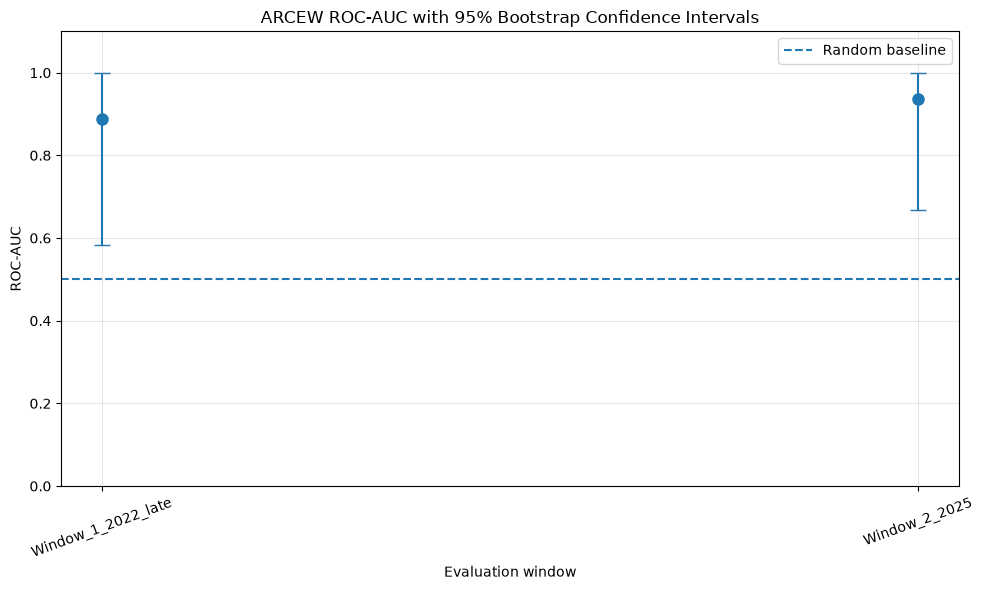

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\final_roc_auc_confidence_intervals.png


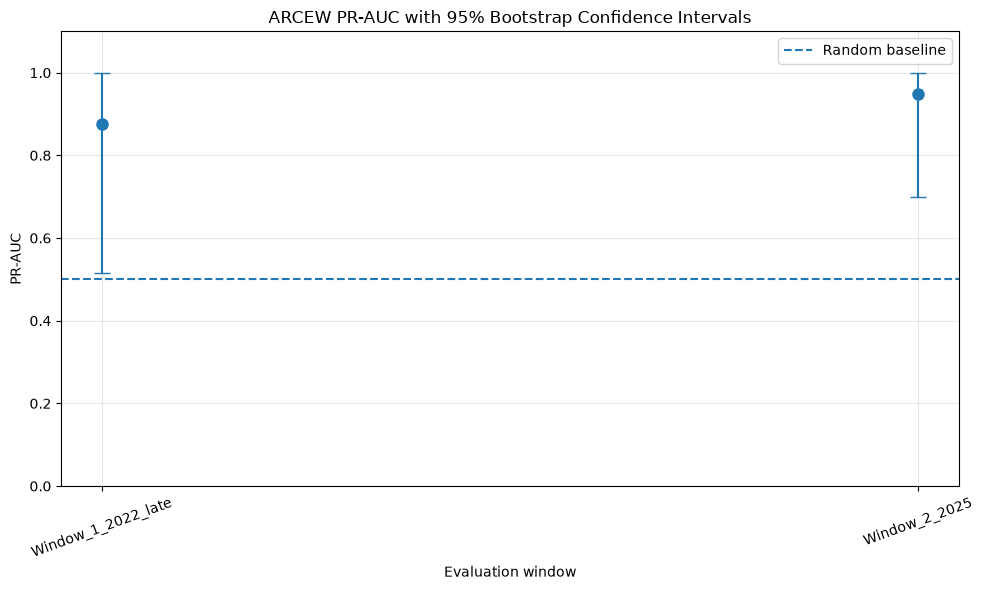

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\final_pr_auc_confidence_intervals.png


In [74]:
# Cell 72: Final metric visualization

import matplotlib.pyplot as plt
import numpy as np

metrics = ["roc_auc", "pr_auc"]
metric_labels = ["ROC-AUC", "PR-AUC"]

for metric, label in zip(metrics, metric_labels):

    estimates = final_metrics_df[metric].values
    lower_ci = final_metrics_df[f"{metric}_lower_ci"].values
    upper_ci = final_metrics_df[f"{metric}_upper_ci"].values

    errors = np.array([
        estimates - lower_ci,
        upper_ci - estimates
    ])

    windows = final_metrics_df["window"].values

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        windows,
        estimates,
        yerr=errors,
        fmt="o",
        capsize=6,
        markersize=8
    )

    plt.axhline(
        0.5,
        linestyle="--",
        label="Random baseline"
    )

    plt.ylim(0, 1.1)
    plt.ylabel(label)
    plt.xlabel("Evaluation window")
    plt.title(
        f"ARCEW {label} with 95% Bootstrap Confidence Intervals"
    )

    plt.xticks(rotation=20)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    output_path = (
        PHASE16_DIR /
        f"final_{metric}_confidence_intervals.png"
    )

    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Saved:", output_path)

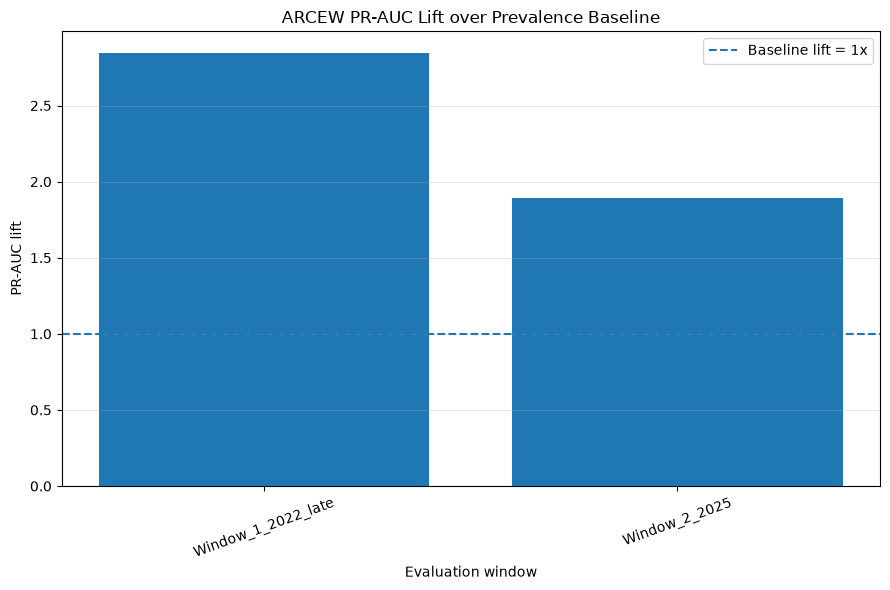

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\final_pr_auc_lift_visualization.png


In [75]:
# Cell 73: PR-AUC lift visualization

plt.figure(figsize=(9, 6))

plt.bar(
    final_metrics_df["window"],
    final_metrics_df["pr_auc_lift"]
)

plt.axhline(
    1.0,
    linestyle="--",
    label="Baseline lift = 1x"
)

plt.ylabel("PR-AUC lift")
plt.xlabel("Evaluation window")
plt.title("ARCEW PR-AUC Lift over Prevalence Baseline")

plt.xticks(rotation=20)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = (
    PHASE16_DIR /
    "final_pr_auc_lift_visualization.png"
)

plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)

In [76]:
# Cell 74: Save research limitations

limitations = [
    {
        "limitation": "Limited evaluation periods",
        "description": (
            "Only two usable event periods were evaluated."
        ),
        "impact": (
            "Generalization across different market regimes "
            "cannot be established."
        )
    },
    {
        "limitation": "Small validation samples",
        "description": (
            "Each evaluation period contains few positive "
            "stress events."
        ),
        "impact": (
            "Performance estimates and confidence intervals "
            "are uncertain."
        )
    },
    {
        "limitation": "Wide confidence intervals",
        "description": (
            "Bootstrap intervals span a wide range."
        ),
        "impact": (
            "Point estimates should not be interpreted as "
            "precise performance measurements."
        )
    },
    {
        "limitation": "No positive test events",
        "description": (
            "The available test period contains no positive "
            "stress events."
        ),
        "impact": (
            "Independent test ROC-AUC and PR-AUC evaluation "
            "is not possible."
        )
    },
    {
        "limitation": "Exploratory findings",
        "description": (
            "The evaluation is based on limited historical data."
        ),
        "impact": (
            "Further validation with additional stress periods "
            "and external datasets is required."
        )
    }
]

limitations_df = pd.DataFrame(limitations)

display(limitations_df)

output_path = (
    PHASE16_DIR /
    "phase16_research_limitations.csv"
)

limitations_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

,limitation,description,impact
0,Limited evaluation periods,Only two usable event periods were evaluated.,Generalization across different market regimes...
1,Small validation samples,Each evaluation period contains few positive s...,Performance estimates and confidence intervals...
2,Wide confidence intervals,Bootstrap intervals span a wide range.,Point estimates should not be interpreted as p...
3,No positive test events,The available test period contains no positive...,Independent test ROC-AUC and PR-AUC evaluation...
4,Exploratory findings,The evaluation is based on limited historical ...,Further validation with additional stress peri...


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\phase16_research_limitations.csv


In [77]:
# Cell 75: Generate Phase 16 research report

from datetime import datetime

report_text = f"""
# FinGraph-Sentinel — Phase 16 Research Report

## Project Module

Adaptive Regime-Aware Contagion Early-Warning System (ARCEW)

## Objective

To evaluate whether temporal network-risk signals can support
early identification of systemic financial stress events.

## Model Architecture

The evaluated composite model uses four standardized features:

1. betweenness_rolling_mean_3
2. betweenness_change
3. systemic_risk_score_change
4. degree_change

Feature standardization and direction selection were performed
using training data only.

## Evaluation Methodology

- Event-aware chronological evaluation
- Training-only standardization
- Training-only feature direction selection
- ROC-AUC evaluation
- PR-AUC evaluation
- Prevalence-baseline comparison
- Bootstrap confidence intervals
- Explainable temporal risk signals

## Evaluation Results

"""

for _, row in final_metrics_df.iterrows():

    report_text += f"""
### {row['window']}

- Validation observations: {int(row['validation_count'])}
- Positive stress events: {int(row['positive_count'])}
- Prevalence baseline: {row['prevalence_baseline']:.4f}
- ROC-AUC: {row['roc_auc']:.4f}
- ROC-AUC 95% CI: {row['roc_auc_lower_ci']:.4f}–{row['roc_auc_upper_ci']:.4f}
- PR-AUC: {row['pr_auc']:.4f}
- PR-AUC 95% CI: {row['pr_auc_lower_ci']:.4f}–{row['pr_auc_upper_ci']:.4f}
- PR-AUC lift: {row['pr_auc_lift']:.2f}x

"""

report_text += """
## Main Findings

1. The four-feature composite produced strong point estimates
   across the two usable evaluation periods.

2. PR-AUC exceeded the prevalence baseline in both periods.

3. The results suggest that combining network and systemic-risk
   temporal signals may be useful for exploratory stress detection.

4. The performance estimates are uncertain because of the limited
   number of evaluation periods and positive events.

## Limitations

1. Only two usable event periods were evaluated.
2. Validation samples contained few positive stress events.
3. Bootstrap confidence intervals were wide.
4. The available test period contained no positive stress events.
5. The results should be treated as exploratory evidence.
6. Generalization to unseen market conditions has not been established.
7. Additional historical stress periods and external datasets are required.

## Conclusion

Phase 16 developed and evaluated a standardized temporal
network-risk composite for the ARCEW research direction.

The initial results are promising but insufficient to establish
robust predictive performance. Future work should focus on
additional data, independent stress periods, stronger validation,
and comparison with established statistical and machine-learning
baselines.

## Research Status

Phase 16 development and exploratory evaluation completed.

Further validation is required before making claims about
production readiness, generalization, or research novelty.
"""

report_path = (
    PHASE16_DIR /
    "PHASE_16_ARCEW_RESEARCH_REPORT.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8"
)

print("Saved:", report_path)

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\PHASE_16_ARCEW_RESEARCH_REPORT.md


In [78]:
# Cell 76: Phase 16 completion checklist

completion_checklist = pd.DataFrame([
    {
        "task": "Temporal feature engineering",
        "status": "Completed"
    },
    {
        "task": "Leakage-safe evaluation",
        "status": "Completed"
    },
    {
        "task": "Event-aware walk-forward evaluation",
        "status": "Completed"
    },
    {
        "task": "Composite risk signal",
        "status": "Completed"
    },
    {
        "task": "Explainable risk alerts",
        "status": "Completed"
    },
    {
        "task": "Alert threshold analysis",
        "status": "Completed"
    },
    {
        "task": "Early-warning lead-time analysis",
        "status": "Completed"
    },
    {
        "task": "Adaptive weighting experiment",
        "status": "Completed"
    },
    {
        "task": "Ablation study",
        "status": "Completed"
    },
    {
        "task": "Bootstrap confidence intervals",
        "status": "Completed"
    },
    {
        "task": "Final visualizations",
        "status": "Completed"
    },
    {
        "task": "Research limitations",
        "status": "Completed"
    },
    {
        "task": "Final research report",
        "status": "Completed"
    }
])

display(completion_checklist)

checklist_path = (
    PHASE16_DIR /
    "phase16_completion_checklist.csv"
)

completion_checklist.to_csv(
    checklist_path,
    index=False
)

print("Saved:", checklist_path)

,task,status
0,Temporal feature engineering,Completed
1,Leakage-safe evaluation,Completed
2,Event-aware walk-forward evaluation,Completed
3,Composite risk signal,Completed
4,Explainable risk alerts,Completed
5,Alert threshold analysis,Completed
6,Early-warning lead-time analysis,Completed
7,Adaptive weighting experiment,Completed
8,Ablation study,Completed
9,Bootstrap confidence intervals,Completed


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase16\phase16_completion_checklist.csv
